In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Set the aesthetic style of the plots
sns.set(style = "whitegrid")
sns.set_palette("Set2")
sns.set_context("talk")

# For reproducibility
np.random.seed(42)


In [17]:
# Load the data
df = pd.read_csv('Cardiac_Catheretization_Diagnosis.csv')

# Convert binary variables to categorical for better visualization
df['sex'] = df['sex'].astype('category')
df['sigdz'] = df['sigdz'].astype('category')
df['tvdlm'] = df['tvdlm'].astype('category')

# Create more descriptive labels for sex and disease status
df['sex_label'] = df['sex'].map({0: 'Female', 1: 'Male'})
df['disease_label'] = df['sigdz'].map({0: 'No Significant Disease', 1: 'Significant Disease'})

# Create age groups for certain visualizations
df['age_group'] = pd.cut(df['age'], 
                         bins=[15, 30, 40, 50, 60, 70, 85],
                         labels=['<30', '30-40', '40-50', '50-60', '60-70', '70+'])

# Display basic information about the dataset
print(f"Dataset shape: {df.shape}")
print(df.head())
print(df.describe())


Dataset shape: (3504, 9)
  sex  age  cad.dur  choleste sigdz tvdlm sex_label           disease_label  \
0   0   73      132     268.0     1   1.0    Female     Significant Disease   
1   0   68       85     120.0     1   1.0    Female     Significant Disease   
2   0   54       45       NaN     1   0.0    Female     Significant Disease   
3   1   58       86     245.0     0   0.0      Male  No Significant Disease   
4   1   56        7     269.0     0   0.0      Male  No Significant Disease   

  age_group  
0       70+  
1     60-70  
2     50-60  
3     50-60  
4     50-60  
               age      cad.dur     choleste
count  3504.000000  3504.000000  2258.000000
mean     52.275685    42.998288   229.928255
std       9.932080    58.156551    50.614585
min      17.000000     0.000000    29.000000
25%      46.000000     4.000000   196.000000
50%      52.000000    18.000000   224.500000
75%      59.000000    60.000000   259.000000
max      82.000000   416.000000   576.000000


In [49]:
# Load the data
df = pd.read_csv('Cardiac_Catheretization_Diagnosis.csv')

# Create more descriptive labels for sex and disease status
df['sex_label'] = df['sex'].map({0: 'Female', 1: 'Male'})
df['disease_label'] = df['sigdz'].map({0: 'No Significant Disease', 1: 'Significant Disease'})

# Ensure sigdz and sex are numeric for aggregation
df['sigdz'] = pd.to_numeric(df['sigdz'])
df['sex'] = pd.to_numeric(df['sex'])

# Create age groups for certain visualizations
df['age_group'] = pd.cut(df['age'], 
                         bins=[15, 30, 40, 50, 60, 70, 85],
                         labels=['<30', '30-40', '40-50', '50-60', '60-70', '70+'])

# Display basic information about the dataset
print(f"Dataset shape: {df.shape}")
print(df.head())
print(df.describe())


Dataset shape: (3504, 9)
   sex  age  cad.dur  choleste  sigdz  tvdlm sex_label  \
0    0   73      132     268.0      1    1.0    Female   
1    0   68       85     120.0      1    1.0    Female   
2    0   54       45       NaN      1    0.0    Female   
3    1   58       86     245.0      0    0.0      Male   
4    1   56        7     269.0      0    0.0      Male   

            disease_label age_group  
0     Significant Disease       70+  
1     Significant Disease     60-70  
2     Significant Disease     50-60  
3  No Significant Disease     50-60  
4  No Significant Disease     50-60  
               sex          age      cad.dur     choleste        sigdz  \
count  3504.000000  3504.000000  3504.000000  2258.000000  3504.000000   
mean      0.313642    52.275685    42.998288   229.928255     0.666096   
std       0.464039     9.932080    58.156551    50.614585     0.471673   
min       0.000000    17.000000     0.000000    29.000000     0.000000   
25%       0.000000    46.000

/var/folders/7b/slgnw5wj06z2j76zhdtpnrdc0000gn/T/ipykernel_55637/2875368266.py:5: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




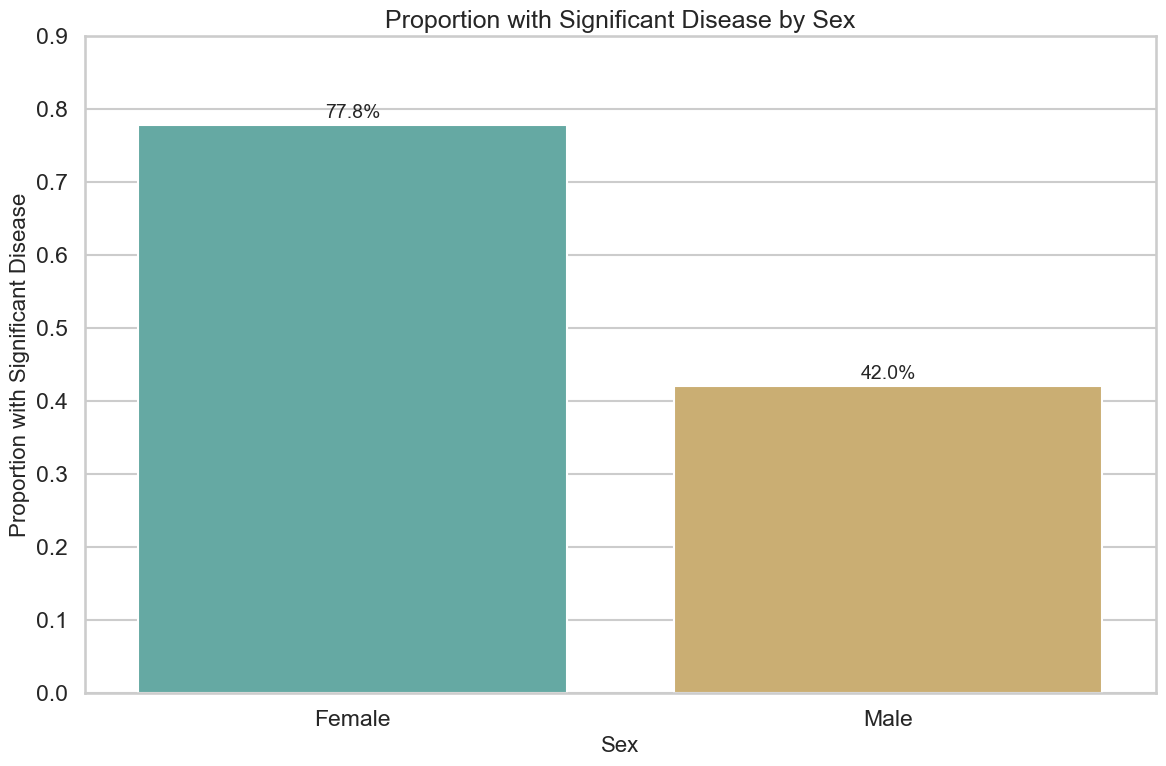

In [51]:
# Calculate proportion of significant disease by sex - using numeric values
disease_by_sex = df.groupby('sex_label')['sigdz'].mean().reset_index()

plt.figure(figsize=(12, 8))
ax = sns.barplot(x='sex_label', y='sigdz', data=disease_by_sex, 
                palette=['#5ab4ac', '#d8b365'])

# Add percentage labels on top of bars
for i, p in enumerate(ax.patches):
    height = p.get_height()
    ax.text(p.get_x() + p.get_width()/2., height + 0.01,
            f'{height:.1%}',
            ha="center", fontsize=14)

plt.title('Proportion with Significant Disease by Sex', fontsize=18)
plt.xlabel('Sex', fontsize=16)
plt.ylabel('Proportion with Significant Disease', fontsize=16)
plt.ylim(0, 0.9)  # Adjust y-axis to leave room for percentage labels
plt.tight_layout()
plt.savefig('Proportion of Significant Disease by Sex.png', dpi=300)
plt.show()


/var/folders/7b/slgnw5wj06z2j76zhdtpnrdc0000gn/T/ipykernel_55637/1267828761.py:16: UserWarning:

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.



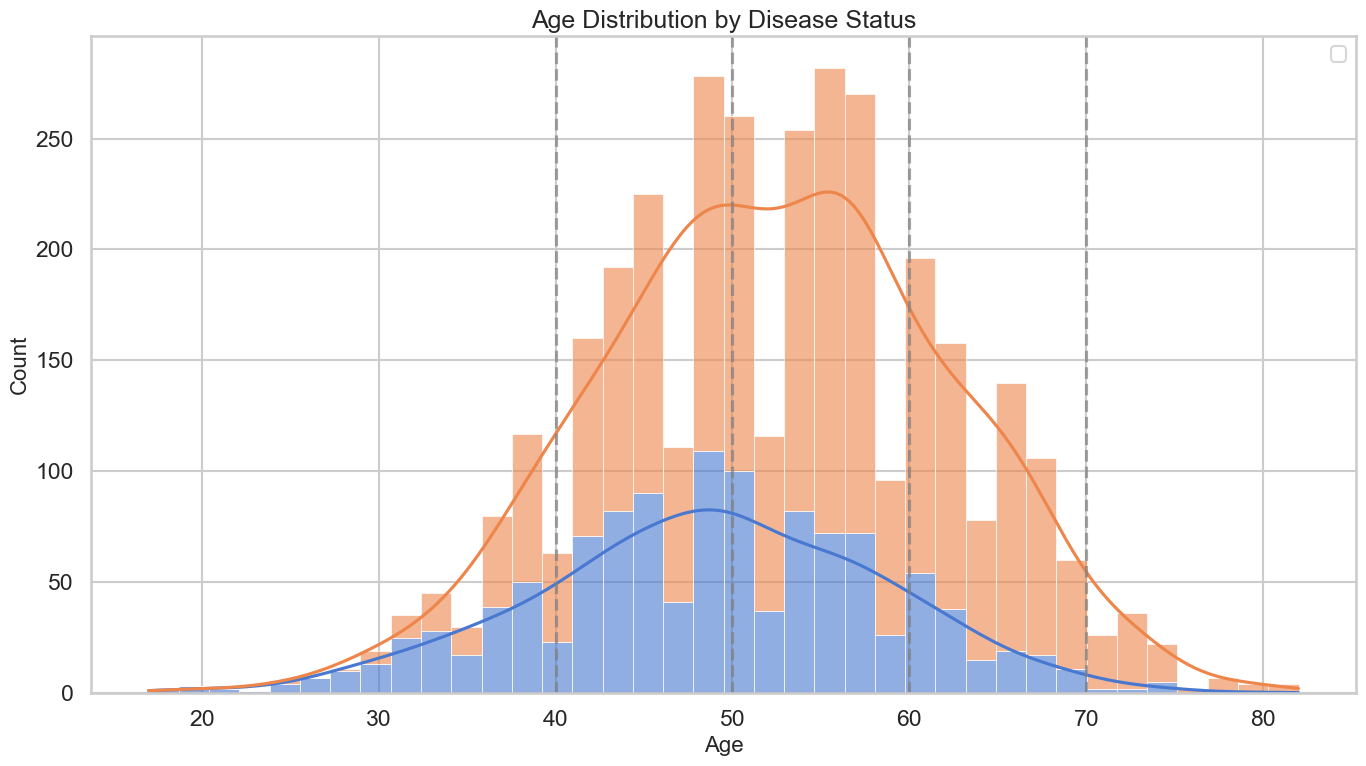

In [53]:
plt.figure(figsize=(14, 8))

# Create a stacked histogram with density curves
ax = sns.histplot(data=df, x='age', hue='disease_label', 
                 multiple='stack', kde=True, 
                 palette={'No Significant Disease': '#4878d0', 'Significant Disease': '#ee854a'},
                 alpha=0.6, edgecolor='white', linewidth=0.5)

# Add vertical reference lines at key age thresholds
for age in [40, 50, 60, 70]:
    plt.axvline(x=age, color='gray', linestyle='--', alpha=0.7)

plt.title('Age Distribution by Disease Status', fontsize=18)
plt.xlabel('Age', fontsize=16)
plt.ylabel('Count', fontsize=16)
plt.legend(title='', fontsize=14)
plt.tight_layout()
plt.savefig('Age Distribution by Disease Status.png', dpi=300)
plt.show()


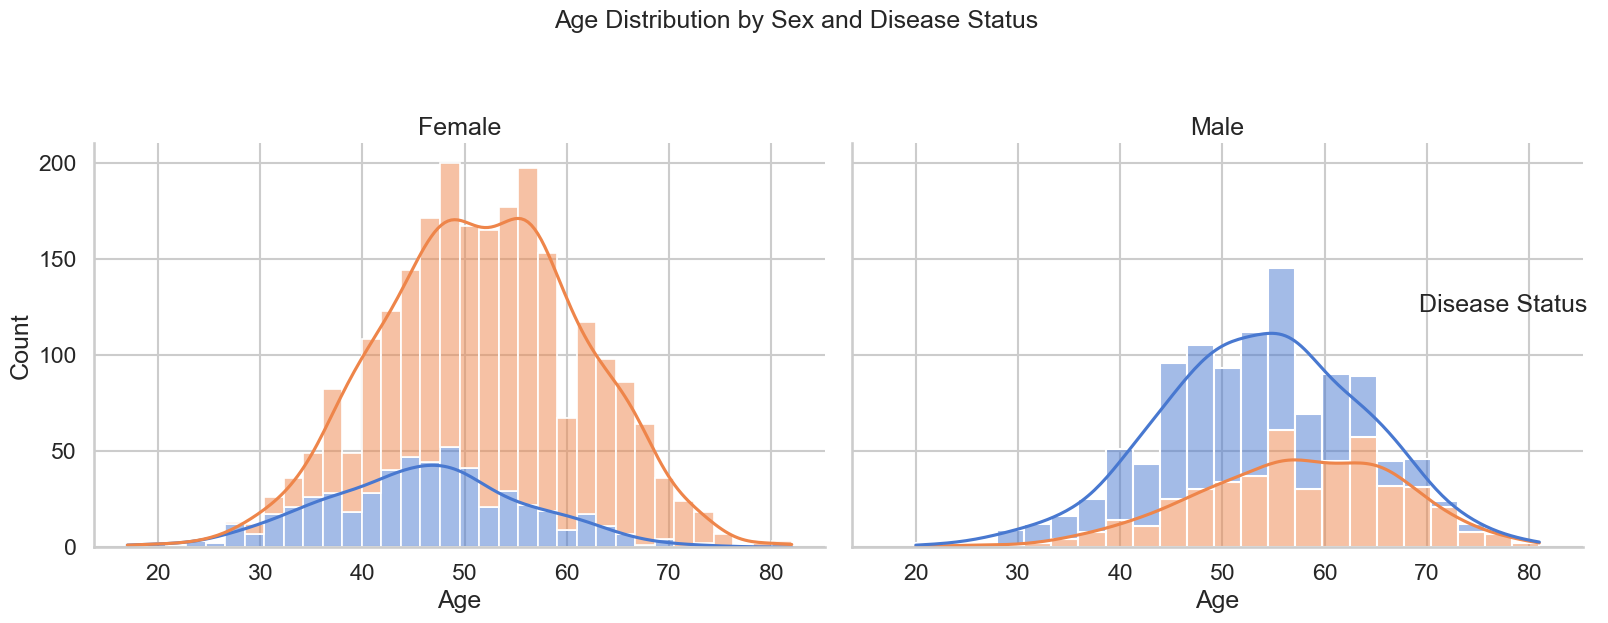

In [55]:
# Create faceted histograms by sex
g = sns.FacetGrid(df, col='sex_label', height=6, aspect=1.2)
g.map_dataframe(sns.histplot, x='age', hue='disease_label', 
               multiple='stack', kde=True, 
               palette={'No Significant Disease': '#4878d0', 'Significant Disease': '#ee854a'})

# Add titles and labels
g.set_axis_labels('Age', 'Count')
g.set_titles('{col_name}')
g.add_legend(title='Disease Status')
g.fig.suptitle('Age Distribution by Sex and Disease Status', y=1.05, fontsize=18)
plt.tight_layout()
plt.savefig('Age Distribution by Sex and Disease Status.png', dpi=300)
plt.show()


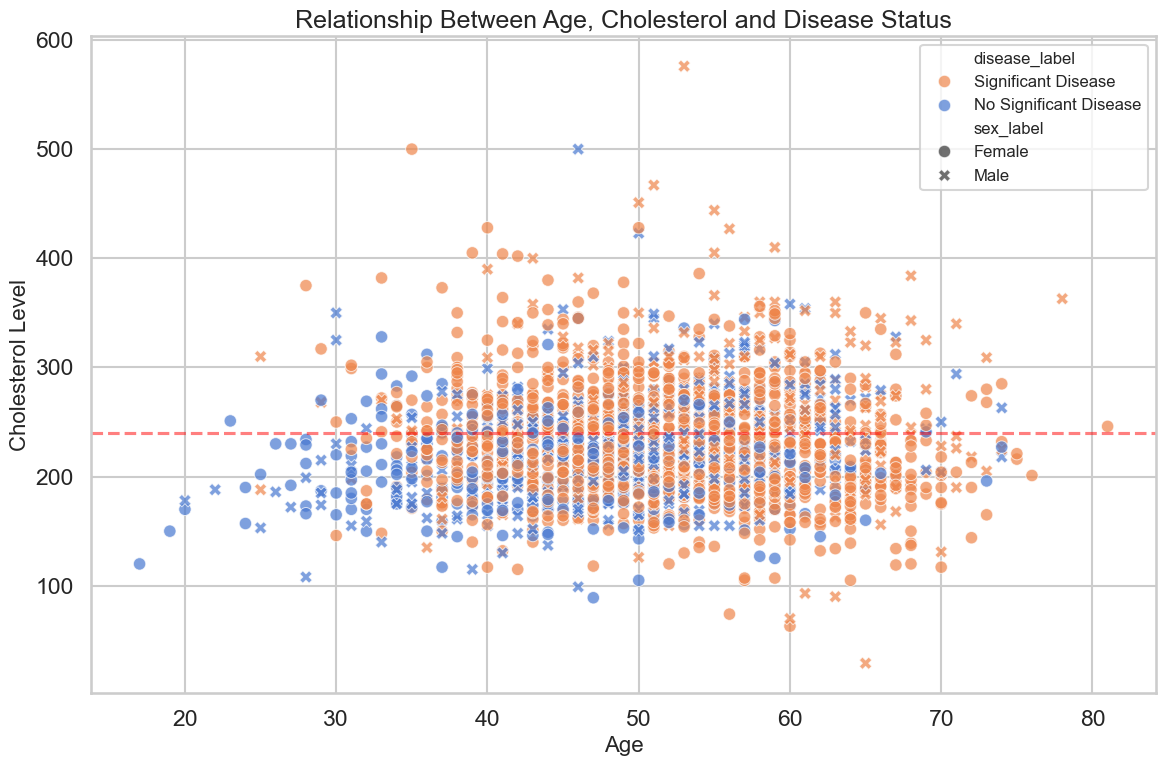

In [57]:
# Drop rows with missing cholesterol values for this visualization
cholesterol_df = df.dropna(subset=['choleste'])

plt.figure(figsize=(12, 8))
scatter = sns.scatterplot(data=cholesterol_df, x='age', y='choleste', 
                         hue='disease_label', style='sex_label', 
                         palette={'No Significant Disease': '#4878d0', 'Significant Disease': '#ee854a'},
                         alpha=0.7, s=80)

plt.title('Relationship Between Age, Cholesterol and Disease Status', fontsize=18)
plt.xlabel('Age', fontsize=16)
plt.ylabel('Cholesterol Level', fontsize=16)
plt.legend(title='', fontsize=12, loc='upper right')

# Add a horizontal line at the typical high cholesterol threshold
plt.axhline(y=240, color='red', linestyle='--', alpha=0.5, label='High Cholesterol Threshold')

plt.tight_layout()
plt.savefig('Age Cholesterol Disease Relationship.png', dpi=300)
plt.show()


/var/folders/7b/slgnw5wj06z2j76zhdtpnrdc0000gn/T/ipykernel_55637/572215819.py:5: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




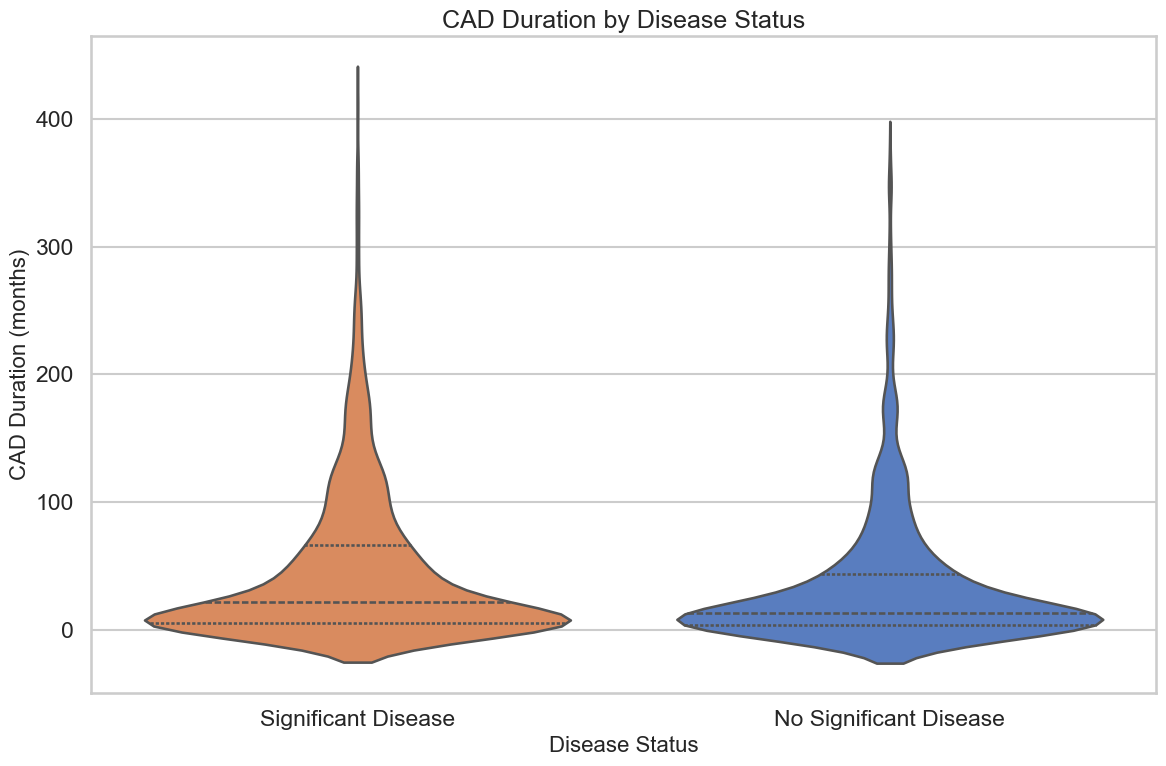

In [59]:
# Drop rows with missing CAD duration values for this visualization
cad_df = df.dropna(subset=['cad.dur'])

plt.figure(figsize=(12, 8))
violin = sns.violinplot(x='disease_label', y='cad.dur', data=cad_df, 
                       palette={'No Significant Disease': '#4878d0', 'Significant Disease': '#ee854a'},
                       inner='quartile')

plt.title('CAD Duration by Disease Status', fontsize=18)
plt.xlabel('Disease Status', fontsize=16)
plt.ylabel('CAD Duration (months)', fontsize=16)
plt.tight_layout()
plt.savefig('CAD Duration by Disease Status.png', dpi=300)
plt.show()


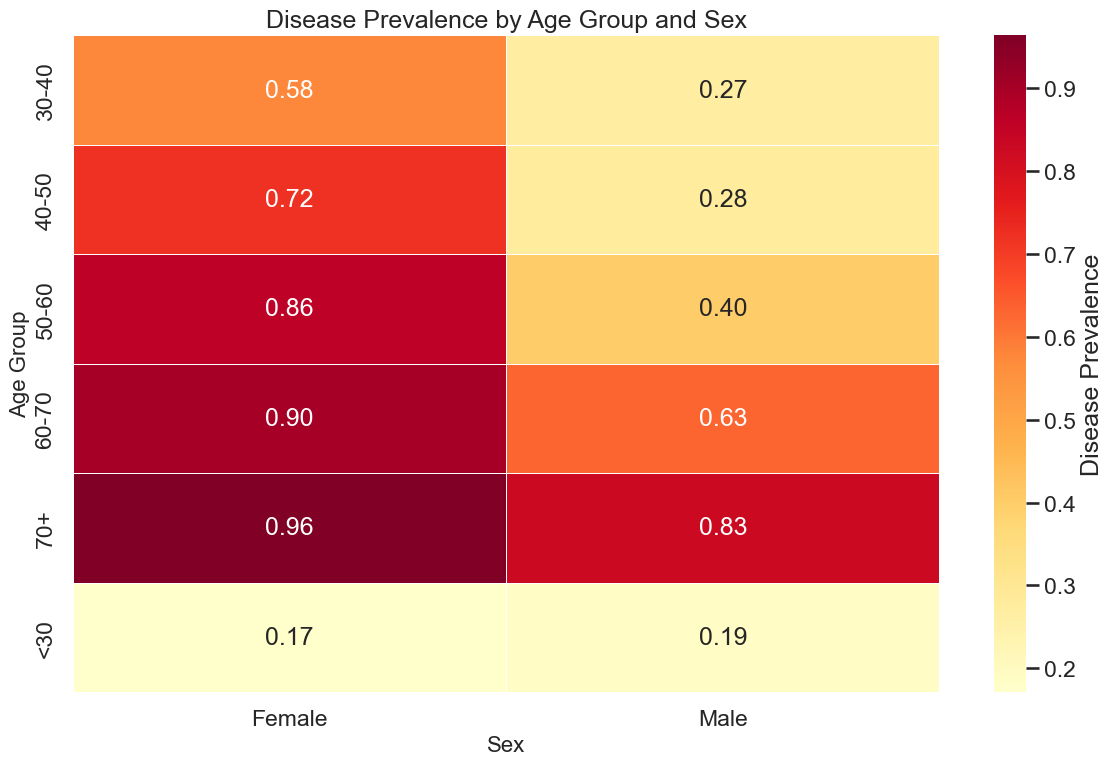

In [61]:
# Calculate disease prevalence by age group and sex - using numeric values
# Convert age_group to string to avoid category issues
df['age_group_str'] = df['age_group'].astype(str)
heatmap_data = df.groupby(['age_group_str', 'sex_label'])['sigdz'].mean().unstack()

plt.figure(figsize=(12, 8))
heatmap = sns.heatmap(heatmap_data, annot=True, cmap='YlOrRd', fmt='.2f', 
                     linewidths=.5, cbar_kws={'label': 'Disease Prevalence'})

plt.title('Disease Prevalence by Age Group and Sex', fontsize=18)
plt.xlabel('Sex', fontsize=16)
plt.ylabel('Age Group', fontsize=16)
plt.tight_layout()
plt.savefig('Disease Prevalence Heatmap.png', dpi=300)
plt.show()


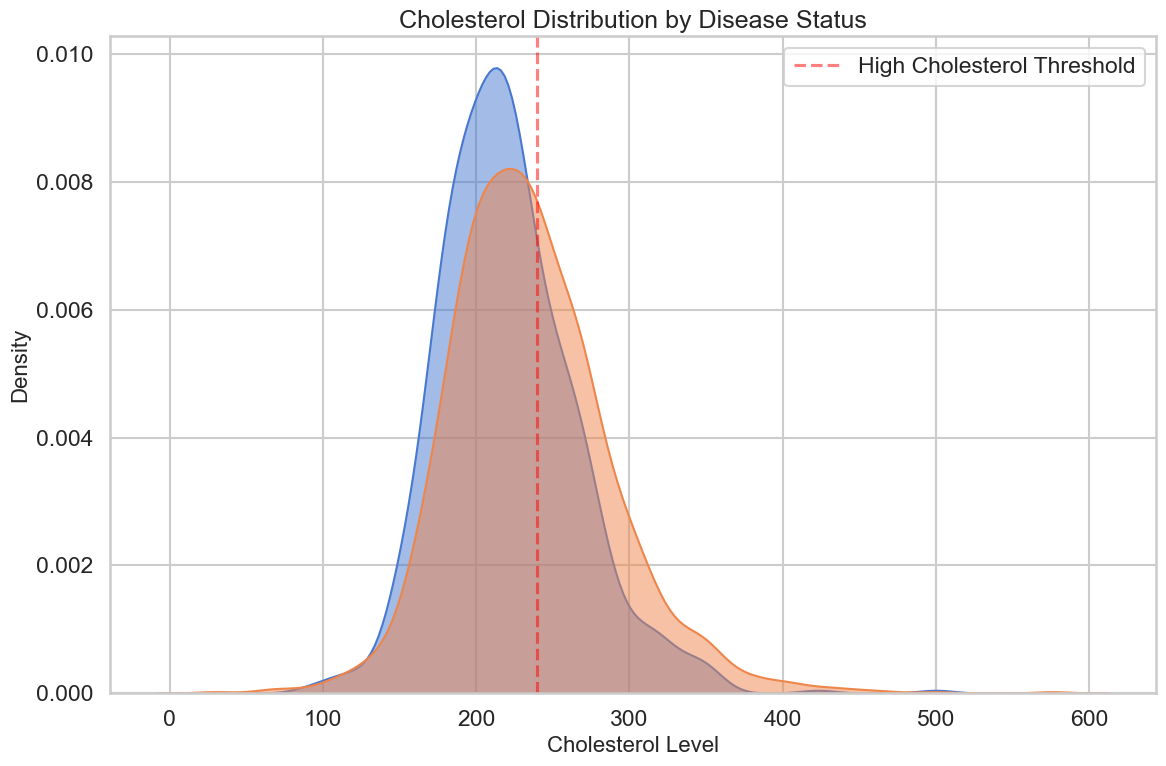

In [63]:
plt.figure(figsize=(12, 8))
sns.kdeplot(data=cholesterol_df, x='choleste', hue='disease_label', 
           fill=True, common_norm=False, alpha=0.5,
           palette={'No Significant Disease': '#4878d0', 'Significant Disease': '#ee854a'})

plt.title('Cholesterol Distribution by Disease Status', fontsize=18)
plt.xlabel('Cholesterol Level', fontsize=16)
plt.ylabel('Density', fontsize=16)
plt.axvline(x=240, color='red', linestyle='--', alpha=0.5, label='High Cholesterol Threshold')
plt.legend(title='')
plt.tight_layout()
plt.savefig('Cholesterol Distribution by Disease Status.png', dpi=300)
plt.show()


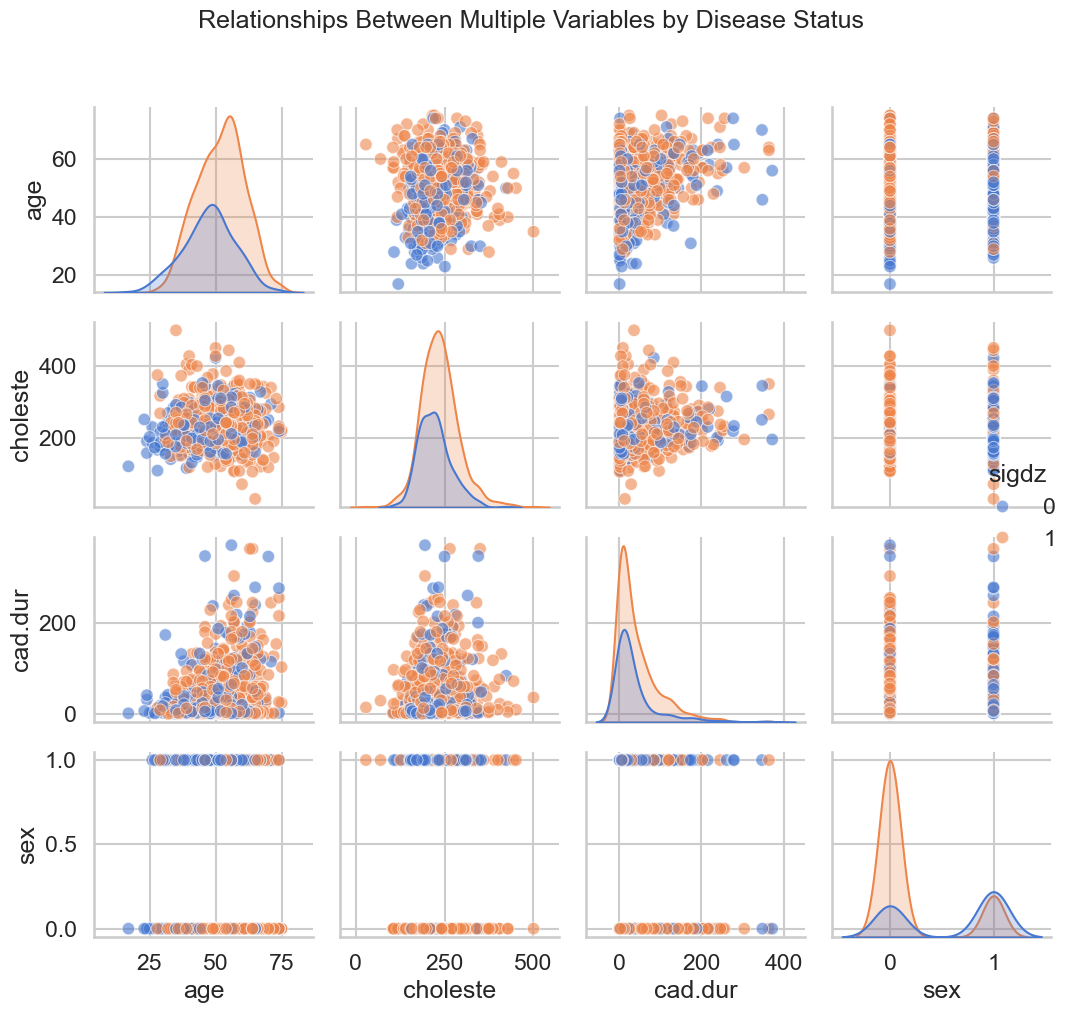

In [65]:
# Select relevant columns and create a sample if dataset is large
# Convert categorical columns to numeric for pairplot
plot_df = df[['age', 'choleste', 'cad.dur', 'sigdz', 'sex']].dropna().sample(n=1000, random_state=42)

# Create pairplot
pairplot = sns.pairplot(plot_df, hue='sigdz', diag_kind='kde', 
                       palette={0: '#4878d0', 1: '#ee854a'},
                       plot_kws={'alpha': 0.6}, height=2.5)

pairplot.fig.suptitle('Relationships Between Multiple Variables by Disease Status', y=1.02, fontsize=18)
plt.tight_layout()
plt.savefig('Multivariate Pairplot.png', dpi=300)
plt.show()


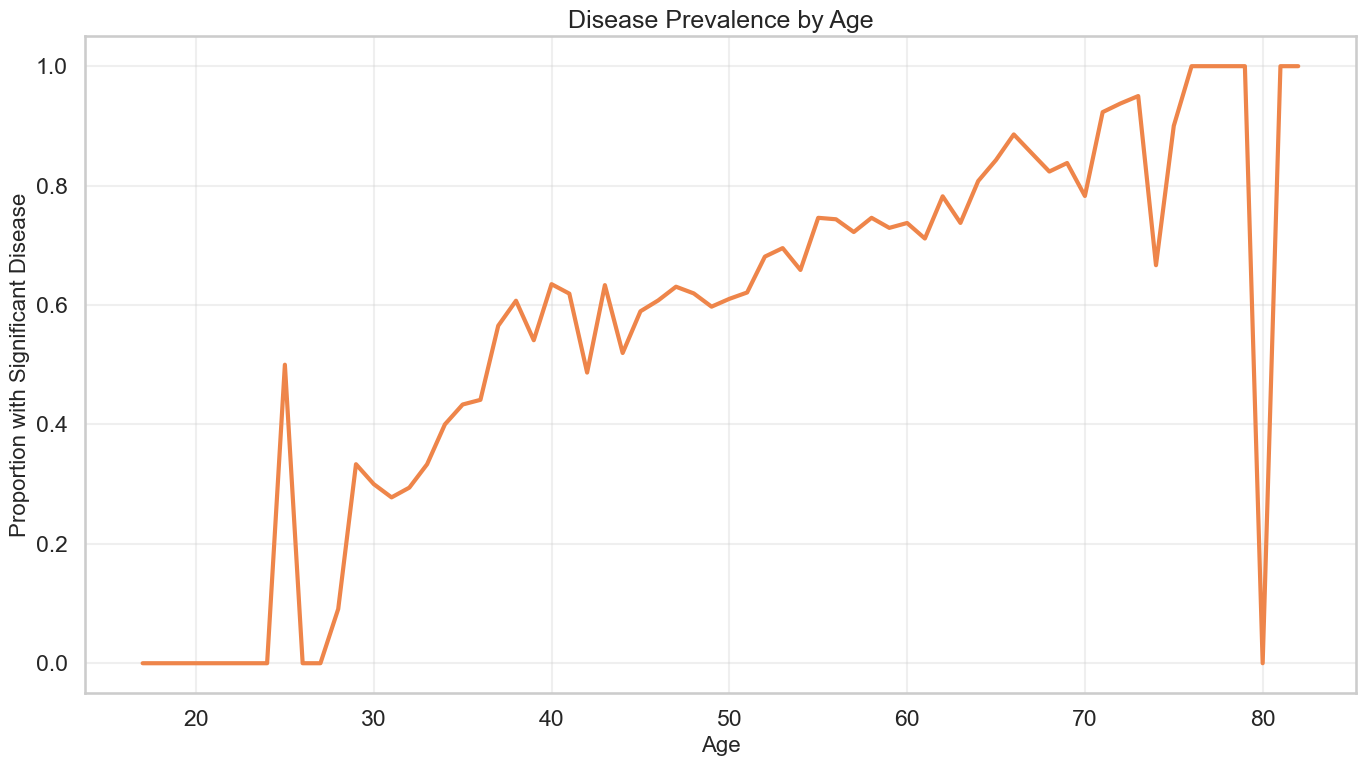

In [67]:
# Calculate disease prevalence by age - using numeric values
age_disease = df.groupby('age')['sigdz'].mean().reset_index()

plt.figure(figsize=(14, 8))
sns.lineplot(x='age', y='sigdz', data=age_disease, linewidth=3, color='#ee854a')

plt.title('Disease Prevalence by Age', fontsize=18)
plt.xlabel('Age', fontsize=16)
plt.ylabel('Proportion with Significant Disease', fontsize=16)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('Disease Prevalence by Age.png', dpi=300)
plt.show()


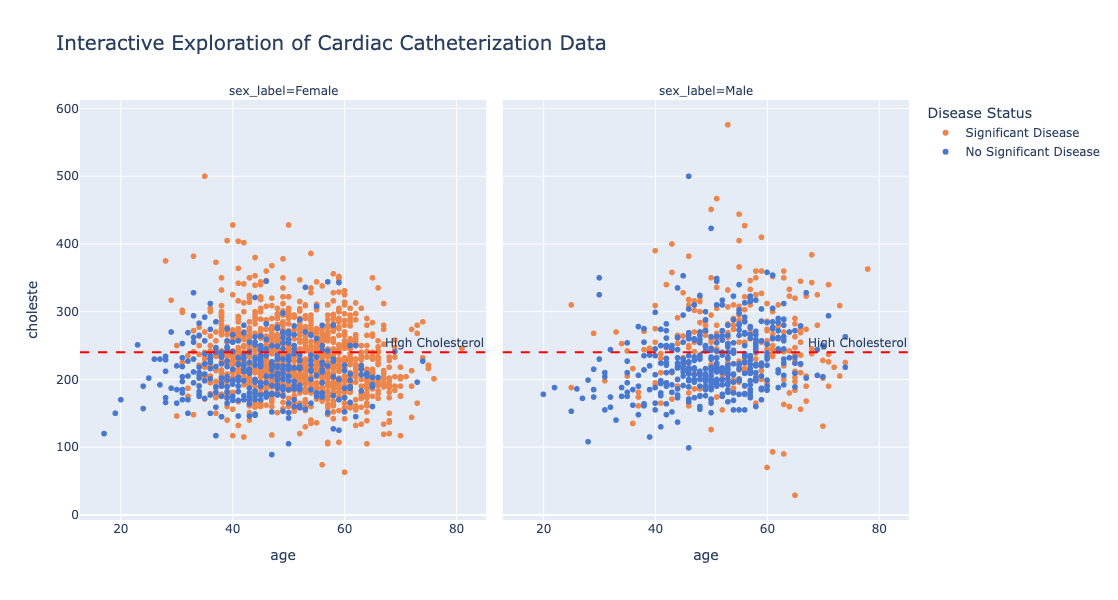

In [69]:
# Create an interactive scatter plot
fig = px.scatter(df.dropna(subset=['choleste']), 
                x='age', y='choleste', color='disease_label', 
                facet_col='sex_label', 
                hover_data=['cad.dur', 'tvdlm'],
                title='Interactive Exploration of Cardiac Catheterization Data',
                color_discrete_map={'No Significant Disease': '#4878d0', 'Significant Disease': '#ee854a'})

# Add a horizontal line for high cholesterol threshold
fig.add_hline(y=240, line_dash="dash", line_color="red", 
              annotation_text="High Cholesterol", 
              annotation_position="top right")

# Improve layout
fig.update_layout(
    height=600, 
    width=1000,
    title_font_size=20,
    legend_title_text='Disease Status'
)

# Show the figure
fig.show()
# Save as HTML for interactive viewing
fig.write_html('Interactive_Cardiac_Data_Visualization.html')


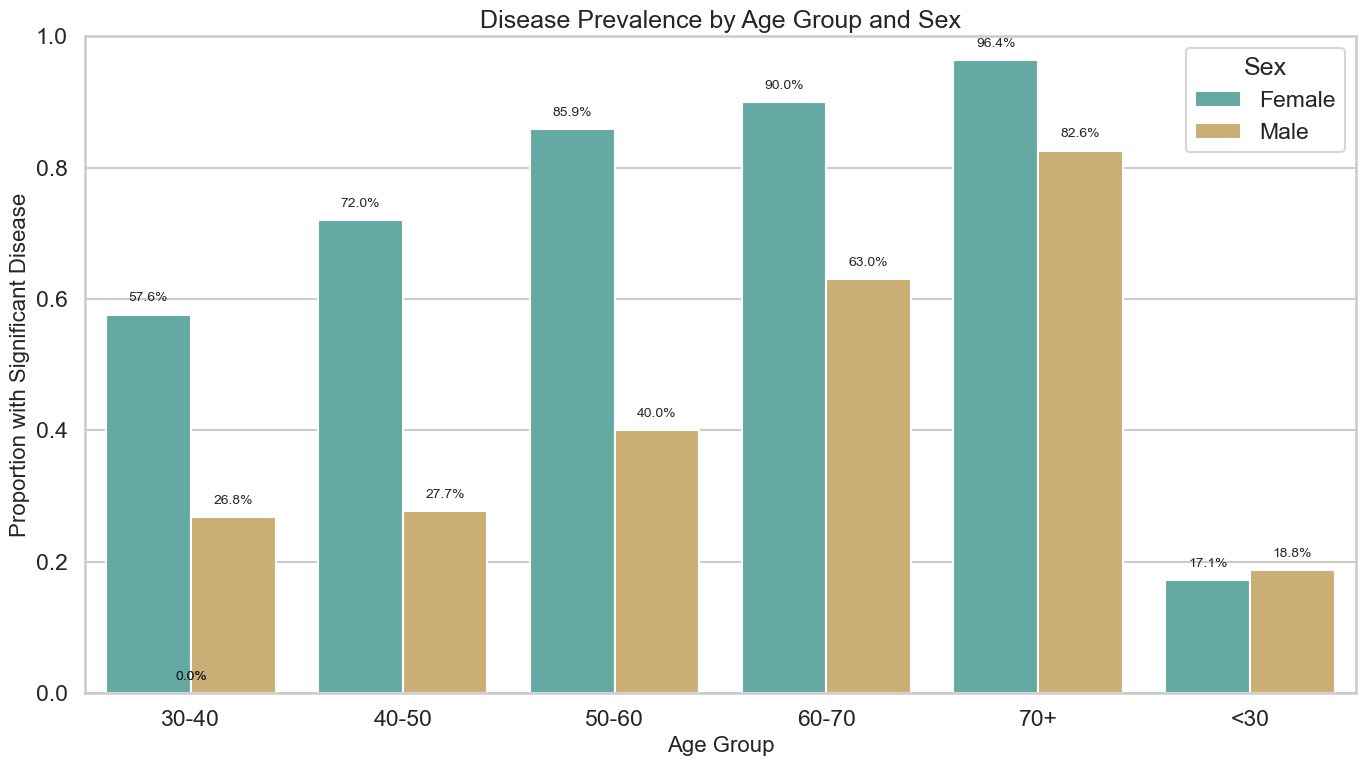

In [71]:
# Calculate disease prevalence by age group and sex - using numeric values
age_sex_disease = df.groupby(['age_group_str', 'sex_label'])['sigdz'].mean().reset_index()

plt.figure(figsize=(14, 8))
bar = sns.barplot(x='age_group_str', y='sigdz', hue='sex_label', data=age_sex_disease,
                 palette=['#5ab4ac', '#d8b365'])

# Add percentage labels on top of bars
for i, p in enumerate(bar.patches):
    height = p.get_height()
    bar.text(p.get_x() + p.get_width()/2., height + 0.02,
            f'{height:.1%}',
            ha="center", fontsize=10)

plt.title('Disease Prevalence by Age Group and Sex', fontsize=18)
plt.xlabel('Age Group', fontsize=16)
plt.ylabel('Proportion with Significant Disease', fontsize=16)
plt.legend(title='Sex')
plt.ylim(0, 1.0)  # Adjust y-axis to leave room for percentage labels
plt.tight_layout()
plt.savefig('Disease Prevalence by Age Group and Sex.png', dpi=300)
plt.show()


/var/folders/7b/slgnw5wj06z2j76zhdtpnrdc0000gn/T/ipykernel_55637/1275644765.py:24: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




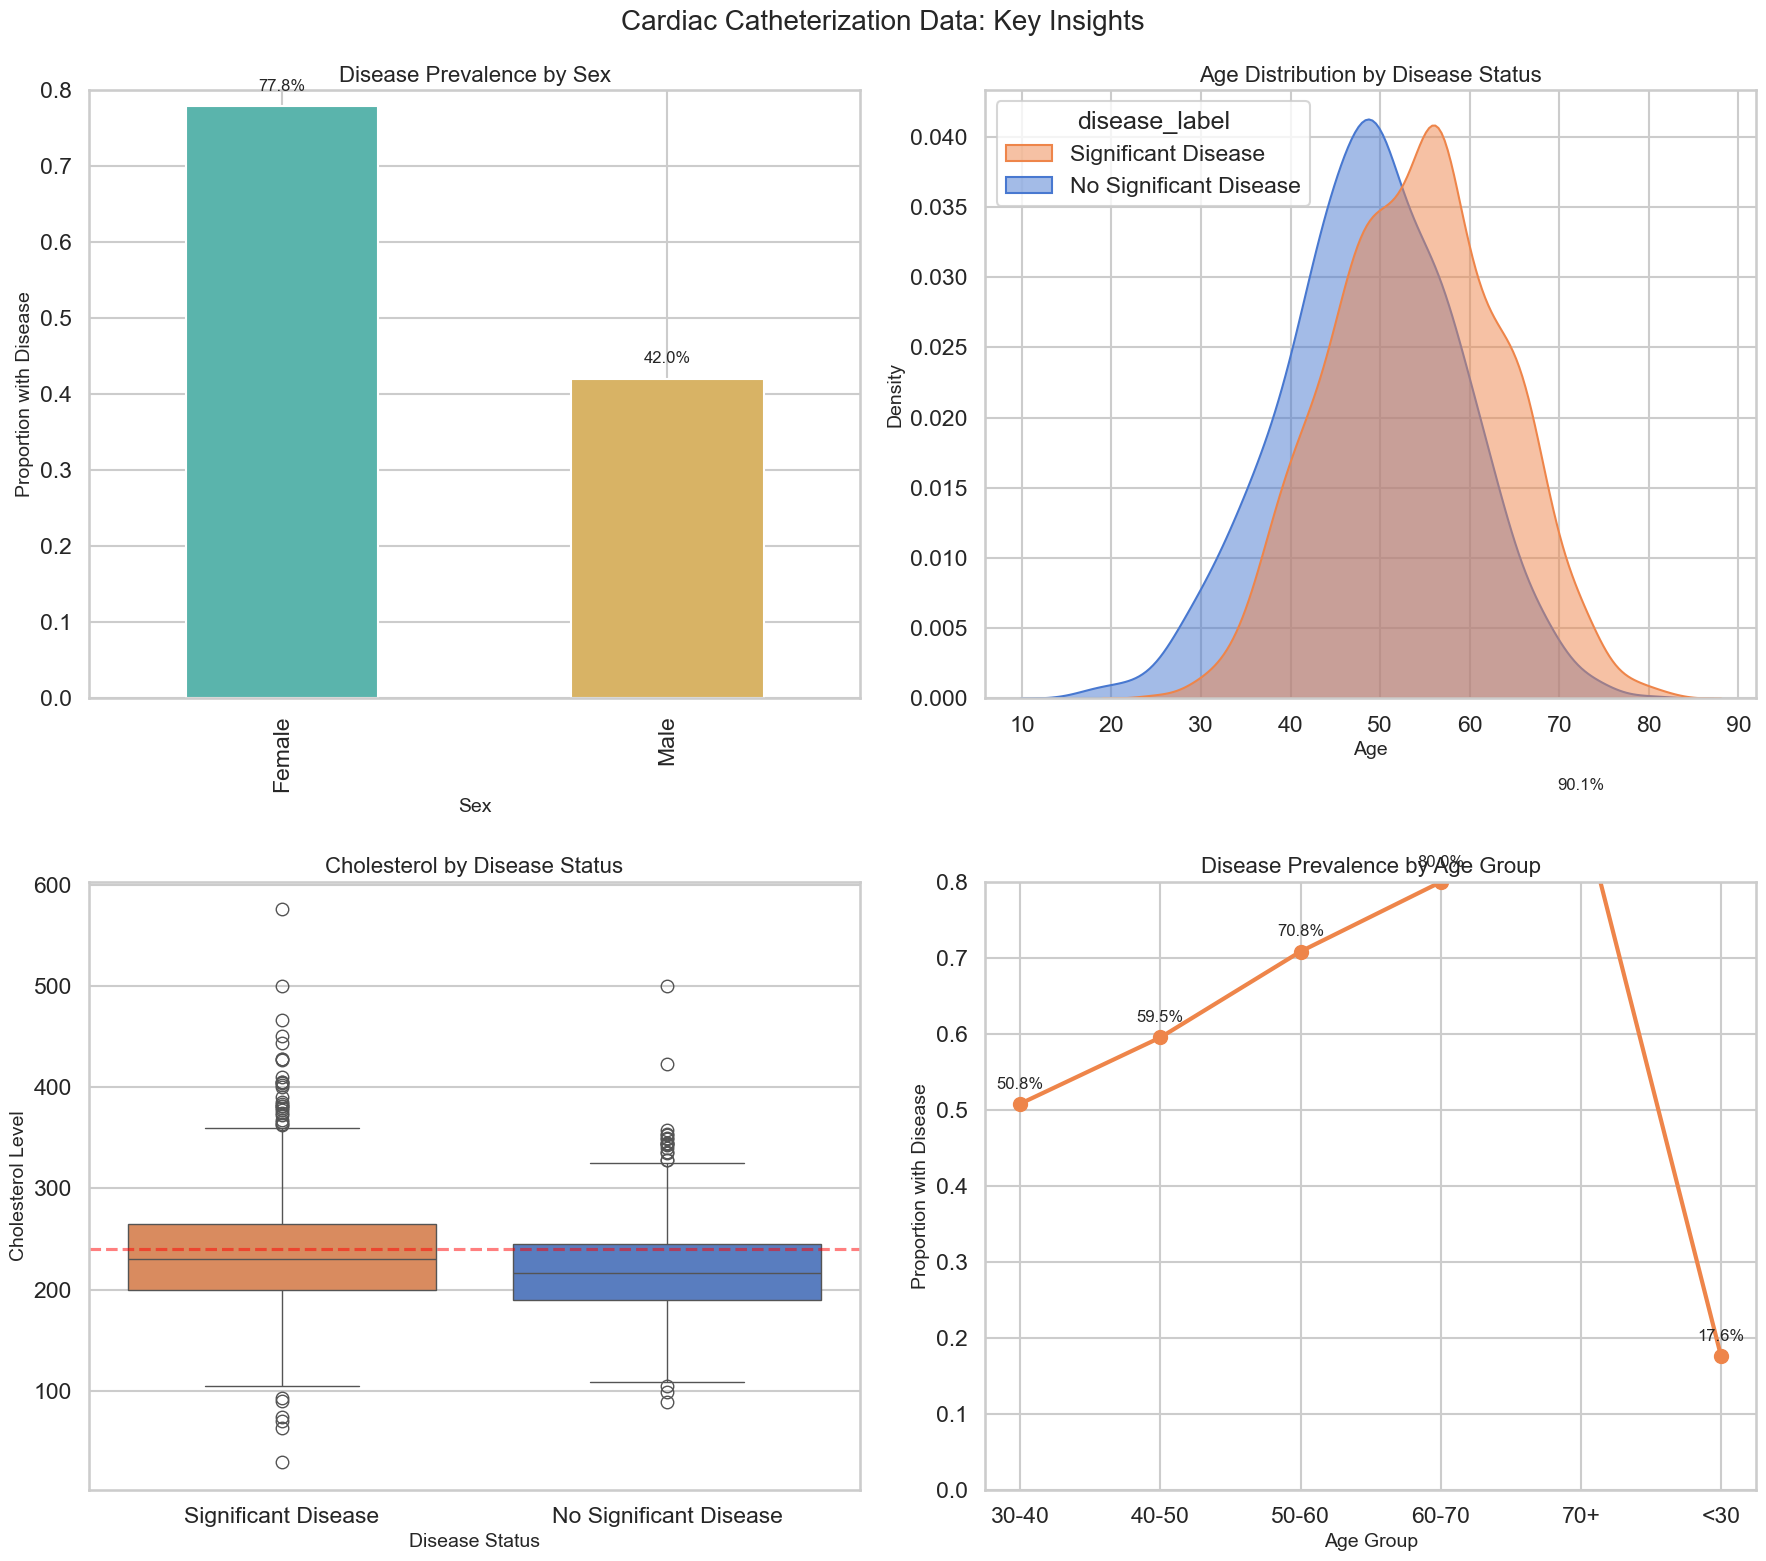

In [73]:
# Create a dashboard with multiple visualizations
fig, axes = plt.subplots(2, 2, figsize=(18, 16))

# Plot 1: Disease prevalence by sex
disease_by_sex = df.groupby('sex_label')['sigdz'].mean()
disease_by_sex.plot(kind='bar', ax=axes[0, 0], color=['#5ab4ac', '#d8b365'])
axes[0, 0].set_title('Disease Prevalence by Sex', fontsize=16)
axes[0, 0].set_xlabel('Sex', fontsize=14)
axes[0, 0].set_ylabel('Proportion with Disease', fontsize=14)
axes[0, 0].set_ylim(0, 0.8)
for i, v in enumerate(disease_by_sex):
    axes[0, 0].text(i, v + 0.02, f'{v:.1%}', ha='center', fontsize=12)

# Plot 2: Age distribution by disease status
sns.kdeplot(data=df, x='age', hue='disease_label', 
           fill=True, common_norm=False, alpha=0.5,
           palette={'No Significant Disease': '#4878d0', 'Significant Disease': '#ee854a'},
           ax=axes[0, 1])
axes[0, 1].set_title('Age Distribution by Disease Status', fontsize=16)
axes[0, 1].set_xlabel('Age', fontsize=14)
axes[0, 1].set_ylabel('Density', fontsize=14)

# Plot 3: Cholesterol by disease status
sns.boxplot(x='disease_label', y='choleste', data=df.dropna(subset=['choleste']), 
           palette={'No Significant Disease': '#4878d0', 'Significant Disease': '#ee854a'},
           ax=axes[1, 0])
axes[1, 0].set_title('Cholesterol by Disease Status', fontsize=16)
axes[1, 0].set_xlabel('Disease Status', fontsize=14)
axes[1, 0].set_ylabel('Cholesterol Level', fontsize=14)
axes[1, 0].axhline(y=240, color='red', linestyle='--', alpha=0.5)

# Plot 4: Disease prevalence by age group
# Convert age_group to string to avoid category issues
age_disease = df.groupby('age_group_str')['sigdz'].mean()
age_disease.plot(kind='line', marker='o', linewidth=3, markersize=10, 
                color='#ee854a', ax=axes[1, 1])
axes[1, 1].set_title('Disease Prevalence by Age Group', fontsize=16)
axes[1, 1].set_xlabel('Age Group', fontsize=14)
axes[1, 1].set_ylabel('Proportion with Disease', fontsize=14)
axes[1, 1].set_ylim(0, 0.8)
for i, v in enumerate(age_disease):
    axes[1, 1].text(i, v + 0.02, f'{v:.1%}', ha='center', fontsize=12)

plt.suptitle('Cardiac Catheterization Data: Key Insights', fontsize=20)
plt.tight_layout()
plt.subplots_adjust(top=0.93)
plt.savefig('Cardiac Data Dashboard.png', dpi=300)
plt.show()


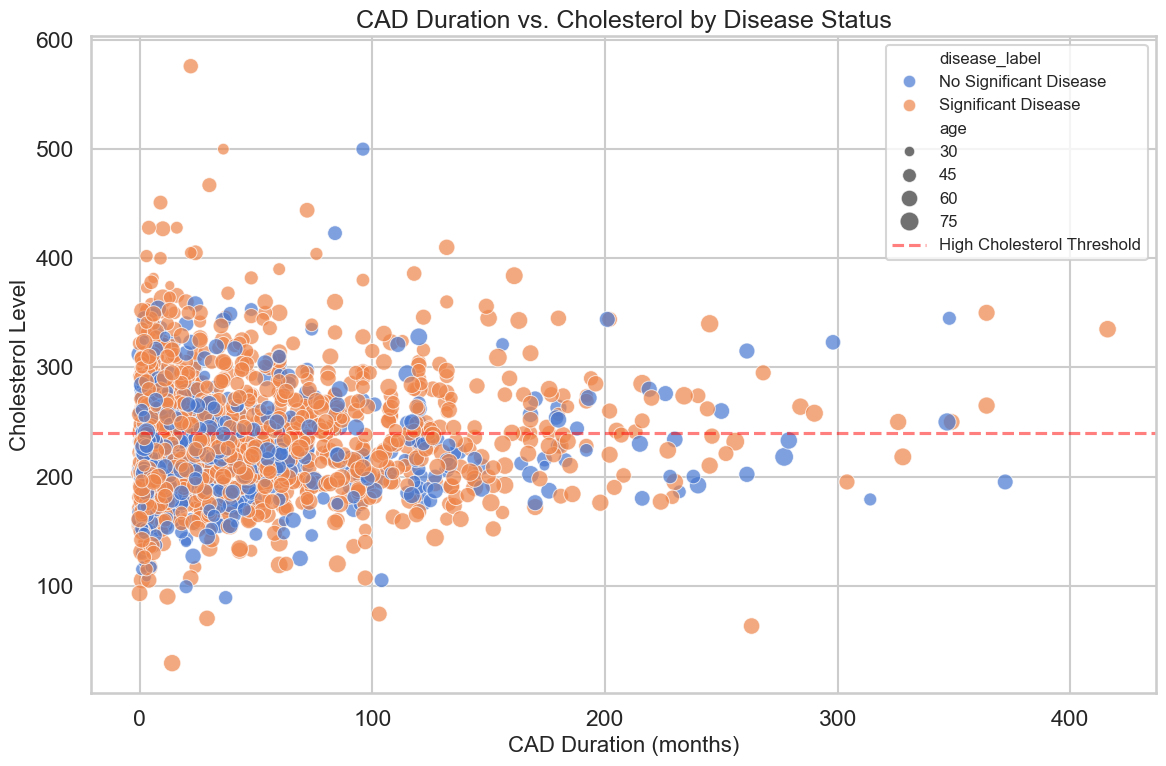

In [41]:
# Create a subset with non-missing values
subset_df = df.dropna(subset=['cad.dur', 'choleste'])

plt.figure(figsize=(12, 8))
scatter = sns.scatterplot(data=subset_df, x='cad.dur', y='choleste', 
                         hue='disease_label', size='age', sizes=(20, 200),
                         palette={'No Significant Disease': '#4878d0', 'Significant Disease': '#ee854a'},
                         alpha=0.7)

plt.title('CAD Duration vs. Cholesterol by Disease Status', fontsize=18)
plt.xlabel('CAD Duration (months)', fontsize=16)
plt.ylabel('Cholesterol Level', fontsize=16)
plt.axhline(y=240, color='red', linestyle='--', alpha=0.5, label='High Cholesterol Threshold')
plt.legend(title='', fontsize=12)
plt.tight_layout()
plt.savefig('CAD Duration vs Cholesterol.png', dpi=300)
plt.show()


/var/folders/7b/slgnw5wj06z2j76zhdtpnrdc0000gn/T/ipykernel_8786/4161061207.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sex', data=df, palette=['#b3cde3', '#fbb4ae'], ax=axes[0, 0])
/var/folders/7b/slgnw5wj06z2j76zhdtpnrdc0000gn/T/ipykernel_8786/4161061207.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0, 0].set_xticklabels(['Male (0)', 'Female (1)'])
/var/folders/7b/slgnw5wj06z2j76zhdtpnrdc0000gn/T/ipykernel_8786/4161061207.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='sex', y='choleste', data=df, palette=['#b3cde3', '#fbb4ae'], ax=axes[1, 0])
/var/folders/7b/slgnw5wj06z2j

<Figure size 2000x1500 with 0 Axes>

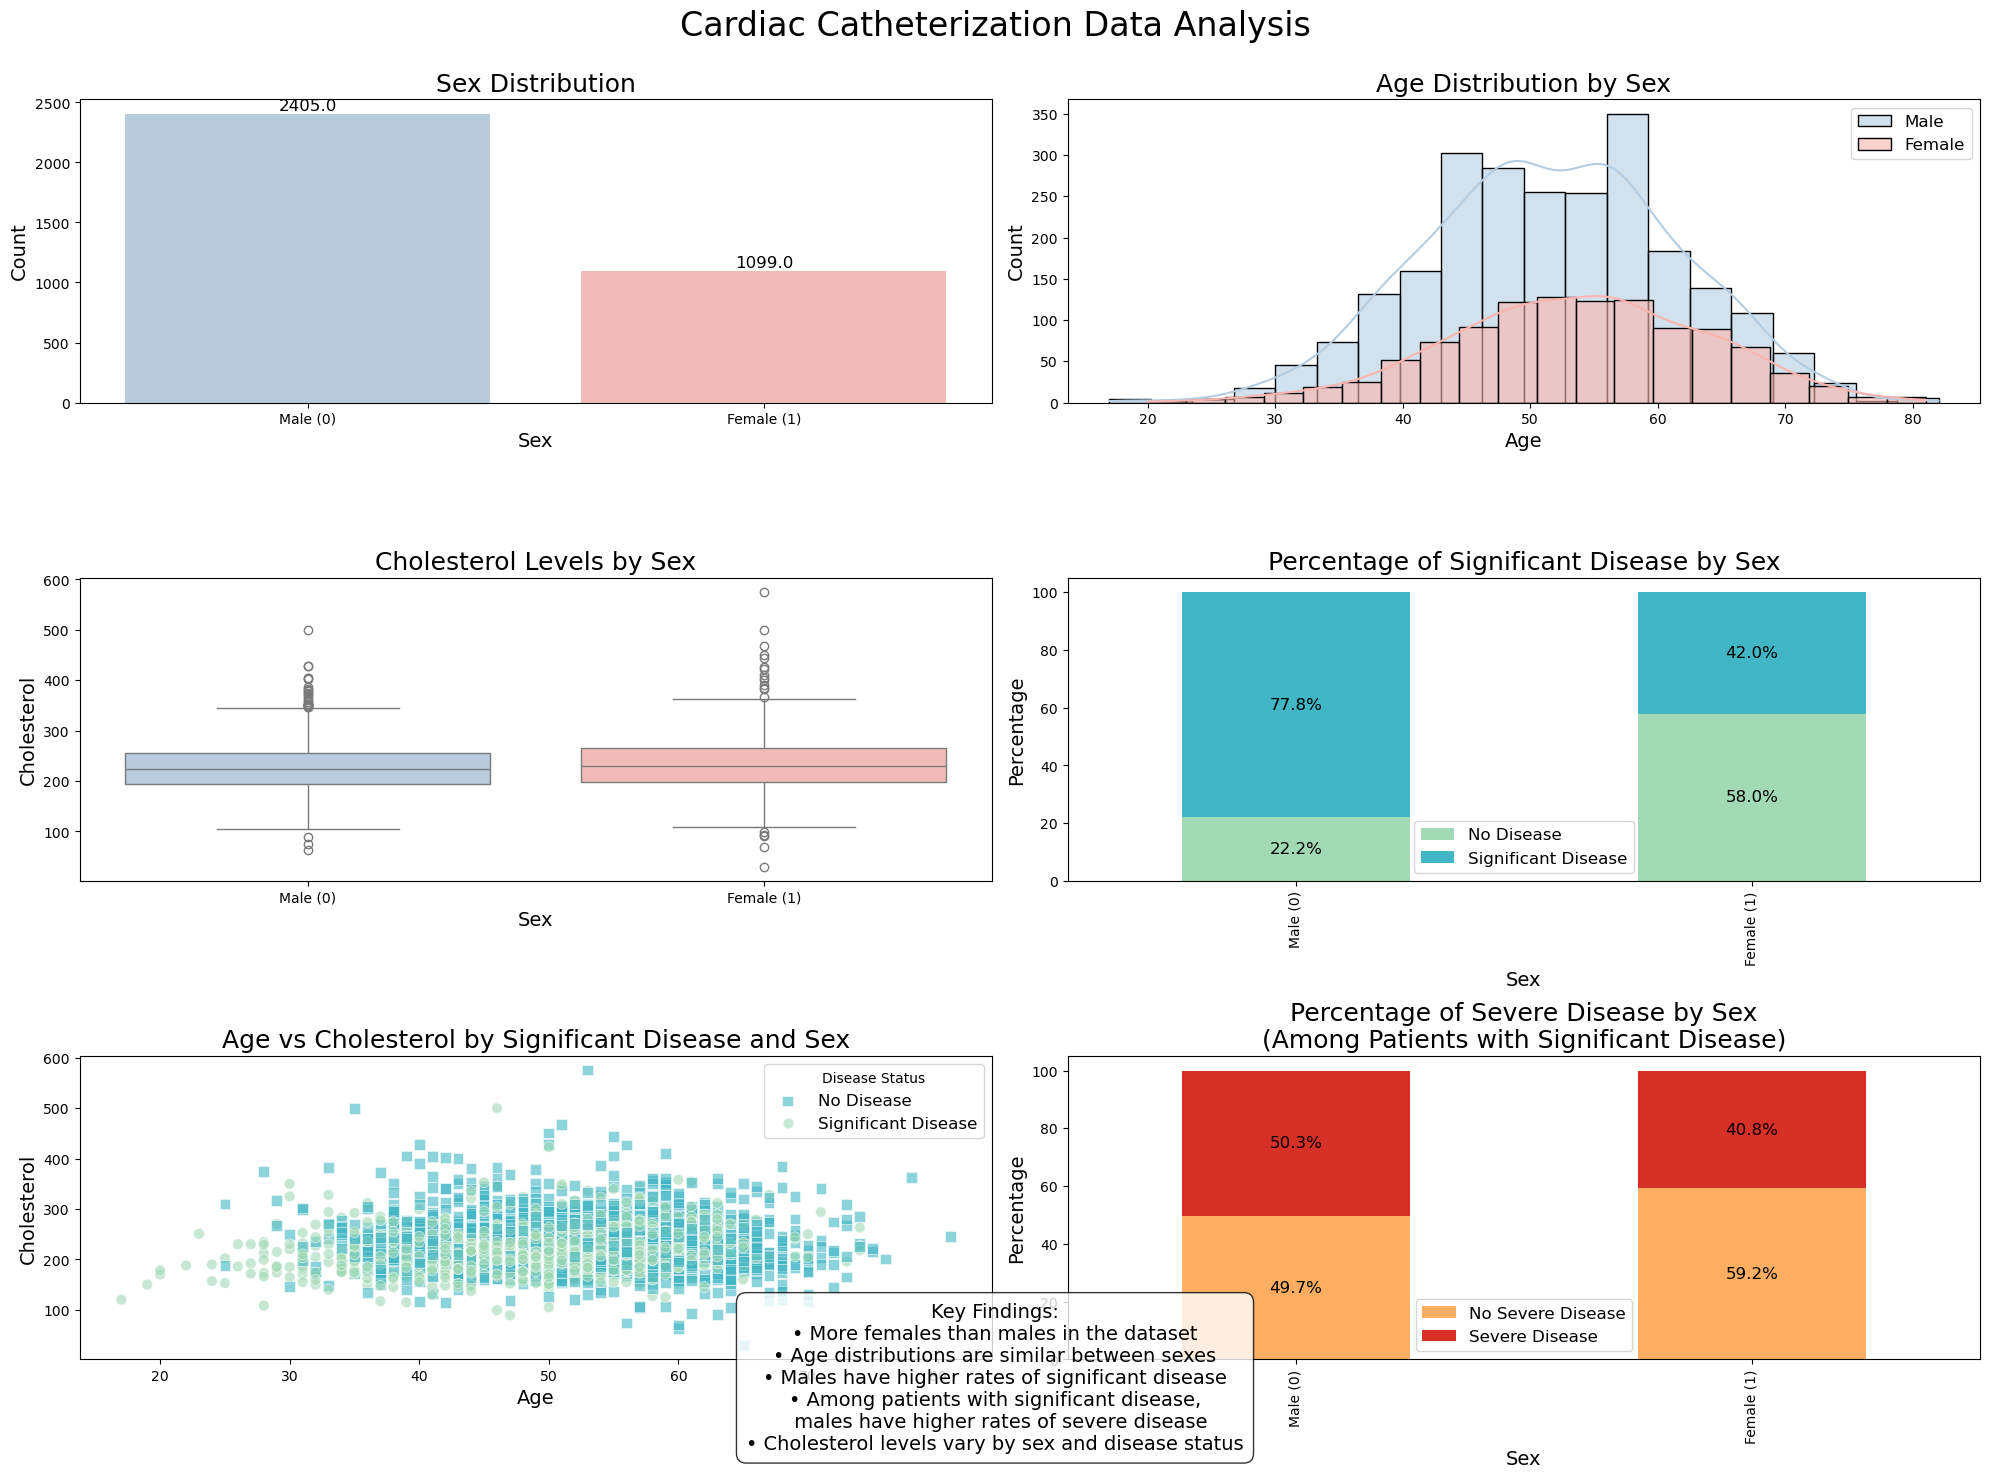

In [1]:
# initial visualizations - prompt #1:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load the dataset
df = pd.read_csv('Cardiac_Catheretization_Diagnosis.csv')

# Set up the figure with subplots for storytelling visuals
plt.figure(figsize=(20, 15))

# Create a 3x2 grid of subplots
fig, axes = plt.subplots(3, 2, figsize=(20, 15))
fig.suptitle('Cardiac Catheterization Data Analysis', fontsize=24, y=0.98)

# Plot 1: Sex Distribution (0=Male, 1=Female)
sns.countplot(x='sex', data=df, palette=['#b3cde3', '#fbb4ae'], ax=axes[0, 0])
axes[0, 0].set_xlabel('Sex', fontsize=14)
axes[0, 0].set_ylabel('Count', fontsize=14)
axes[0, 0].set_title('Sex Distribution', fontsize=18)
axes[0, 0].set_xticklabels(['Male (0)', 'Female (1)'])

# Add count labels on top of bars
for i, p in enumerate(axes[0, 0].patches):
    height = p.get_height()
    axes[0, 0].text(p.get_x() + p.get_width()/2., height + 30,
                   f'{height}', ha="center", fontsize=12)

# Plot 2: Age Distribution by Sex
for sex_value, sex_label, color in [(0, 'Male', '#b3cde3'), (1, 'Female', '#fbb4ae')]:
    subset = df[df['sex'] == sex_value]
    sns.histplot(subset['age'], bins=20, kde=True, 
                label=sex_label, color=color, alpha=0.6, ax=axes[0, 1])
axes[0, 1].set_xlabel('Age', fontsize=14)
axes[0, 1].set_ylabel('Count', fontsize=14)
axes[0, 1].set_title('Age Distribution by Sex', fontsize=18)
axes[0, 1].legend(fontsize=12)

# Plot 3: Cholesterol Levels by Sex
sns.boxplot(x='sex', y='choleste', data=df, palette=['#b3cde3', '#fbb4ae'], ax=axes[1, 0])
axes[1, 0].set_xlabel('Sex', fontsize=14)
axes[1, 0].set_xticklabels(['Male (0)', 'Female (1)'])
axes[1, 0].set_ylabel('Cholesterol', fontsize=14)
axes[1, 0].set_title('Cholesterol Levels by Sex', fontsize=18)

# Plot 4: Percentage of Significant Disease by Sex
ct = pd.crosstab(df['sex'], df['sigdz'])
ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100
ct_pct.plot(kind='bar', stacked=True, color=['#a1dab4', '#41b6c4'], ax=axes[1, 1])
axes[1, 1].set_xlabel('Sex', fontsize=14)
axes[1, 1].set_xticklabels(['Male (0)', 'Female (1)'])
axes[1, 1].set_ylabel('Percentage', fontsize=14)
axes[1, 1].set_title('Percentage of Significant Disease by Sex', fontsize=18)
axes[1, 1].legend(['No Disease', 'Significant Disease'], fontsize=12)

# Add percentage labels on bars
for i, p in enumerate(axes[1, 1].patches):
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy() 
    if height > 5:  # Only label if percentage is significant
        axes[1, 1].annotate(f'{height:.1f}%', (x + width/2, y + height/2), 
                    ha='center', va='center', fontsize=12)

# Plot 5: Age vs Cholesterol Scatter Plot with Disease Status
colors = {0: '#a1dab4', 1: '#41b6c4'}
markers = {0: 'o', 1: 's'}

for sex_value in [0, 1]:
    subset = df[df['sex'] == sex_value]
    sns.scatterplot(x='age', y='choleste', hue='sigdz', data=subset, palette=colors, 
                    style='sigdz', markers=markers, alpha=0.6, s=60, ax=axes[2, 0])
axes[2, 0].set_xlabel('Age', fontsize=14)
axes[2, 0].set_ylabel('Cholesterol', fontsize=14)
axes[2, 0].set_title('Age vs Cholesterol by Significant Disease and Sex', fontsize=18)
axes[2, 0].legend(['No Disease', 'Significant Disease'], fontsize=12, title='Disease Status')

# Plot 6: Percentage of Severe Disease by Sex (for patients with significant disease)
sigdz_patients = df[df['sigdz'] == 1]
ct_severe = pd.crosstab(sigdz_patients['sex'], sigdz_patients['tvdlm'])
ct_severe_pct = ct_severe.div(ct_severe.sum(axis=1), axis=0) * 100
ct_severe_pct.plot(kind='bar', stacked=True, color=['#fdae61', '#d73027'], ax=axes[2, 1])
axes[2, 1].set_xlabel('Sex', fontsize=14)
axes[2, 1].set_xticklabels(['Male (0)', 'Female (1)'])
axes[2, 1].set_ylabel('Percentage', fontsize=14)
axes[2, 1].set_title('Percentage of Severe Disease by Sex\n(Among Patients with Significant Disease)', fontsize=18)
axes[2, 1].legend(['No Severe Disease', 'Severe Disease'], fontsize=12)

# Add percentage labels on bars
for i, p in enumerate(axes[2, 1].patches):
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy() 
    if height > 5:  # Only label if percentage is significant
        axes[2, 1].annotate(f'{height:.1f}%', (x + width/2, y + height/2), 
                    ha='center', va='center', fontsize=12)

# Add a descriptive text box with key findings
textstr = '\n'.join((
    'Key Findings:',
    '• More females than males in the dataset',
    '• Age distributions are similar between sexes',
    '• Males have higher rates of significant disease',
    '• Among patients with significant disease,',
    '  males have higher rates of severe disease',
    '• Cholesterol levels vary by sex and disease status'
))

fig.text(0.5, 0.02, textstr, fontsize=14, 
         bbox=dict(facecolor='white', alpha=0.8, boxstyle='round,pad=0.5'),
         ha='center')

# Adjust layout
plt.tight_layout()
plt.subplots_adjust(top=0.92, bottom=0.08)
plt.show()


/var/folders/7b/slgnw5wj06z2j76zhdtpnrdc0000gn/T/ipykernel_8786/657963421.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sex', data=df, palette=['#b3cde3', '#fbb4ae'], ax=axes[0, 0])
/var/folders/7b/slgnw5wj06z2j76zhdtpnrdc0000gn/T/ipykernel_8786/657963421.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0, 0].set_xticklabels(['Male (0)', 'Female (1)'])
/var/folders/7b/slgnw5wj06z2j76zhdtpnrdc0000gn/T/ipykernel_8786/657963421.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='sex', y='choleste', data=df, palette=['#b3cde3', '#fbb4ae'], ax=axes[1, 0])
/var/folders/7b/slgnw5wj06z2j76z

<Figure size 2000x1500 with 0 Axes>

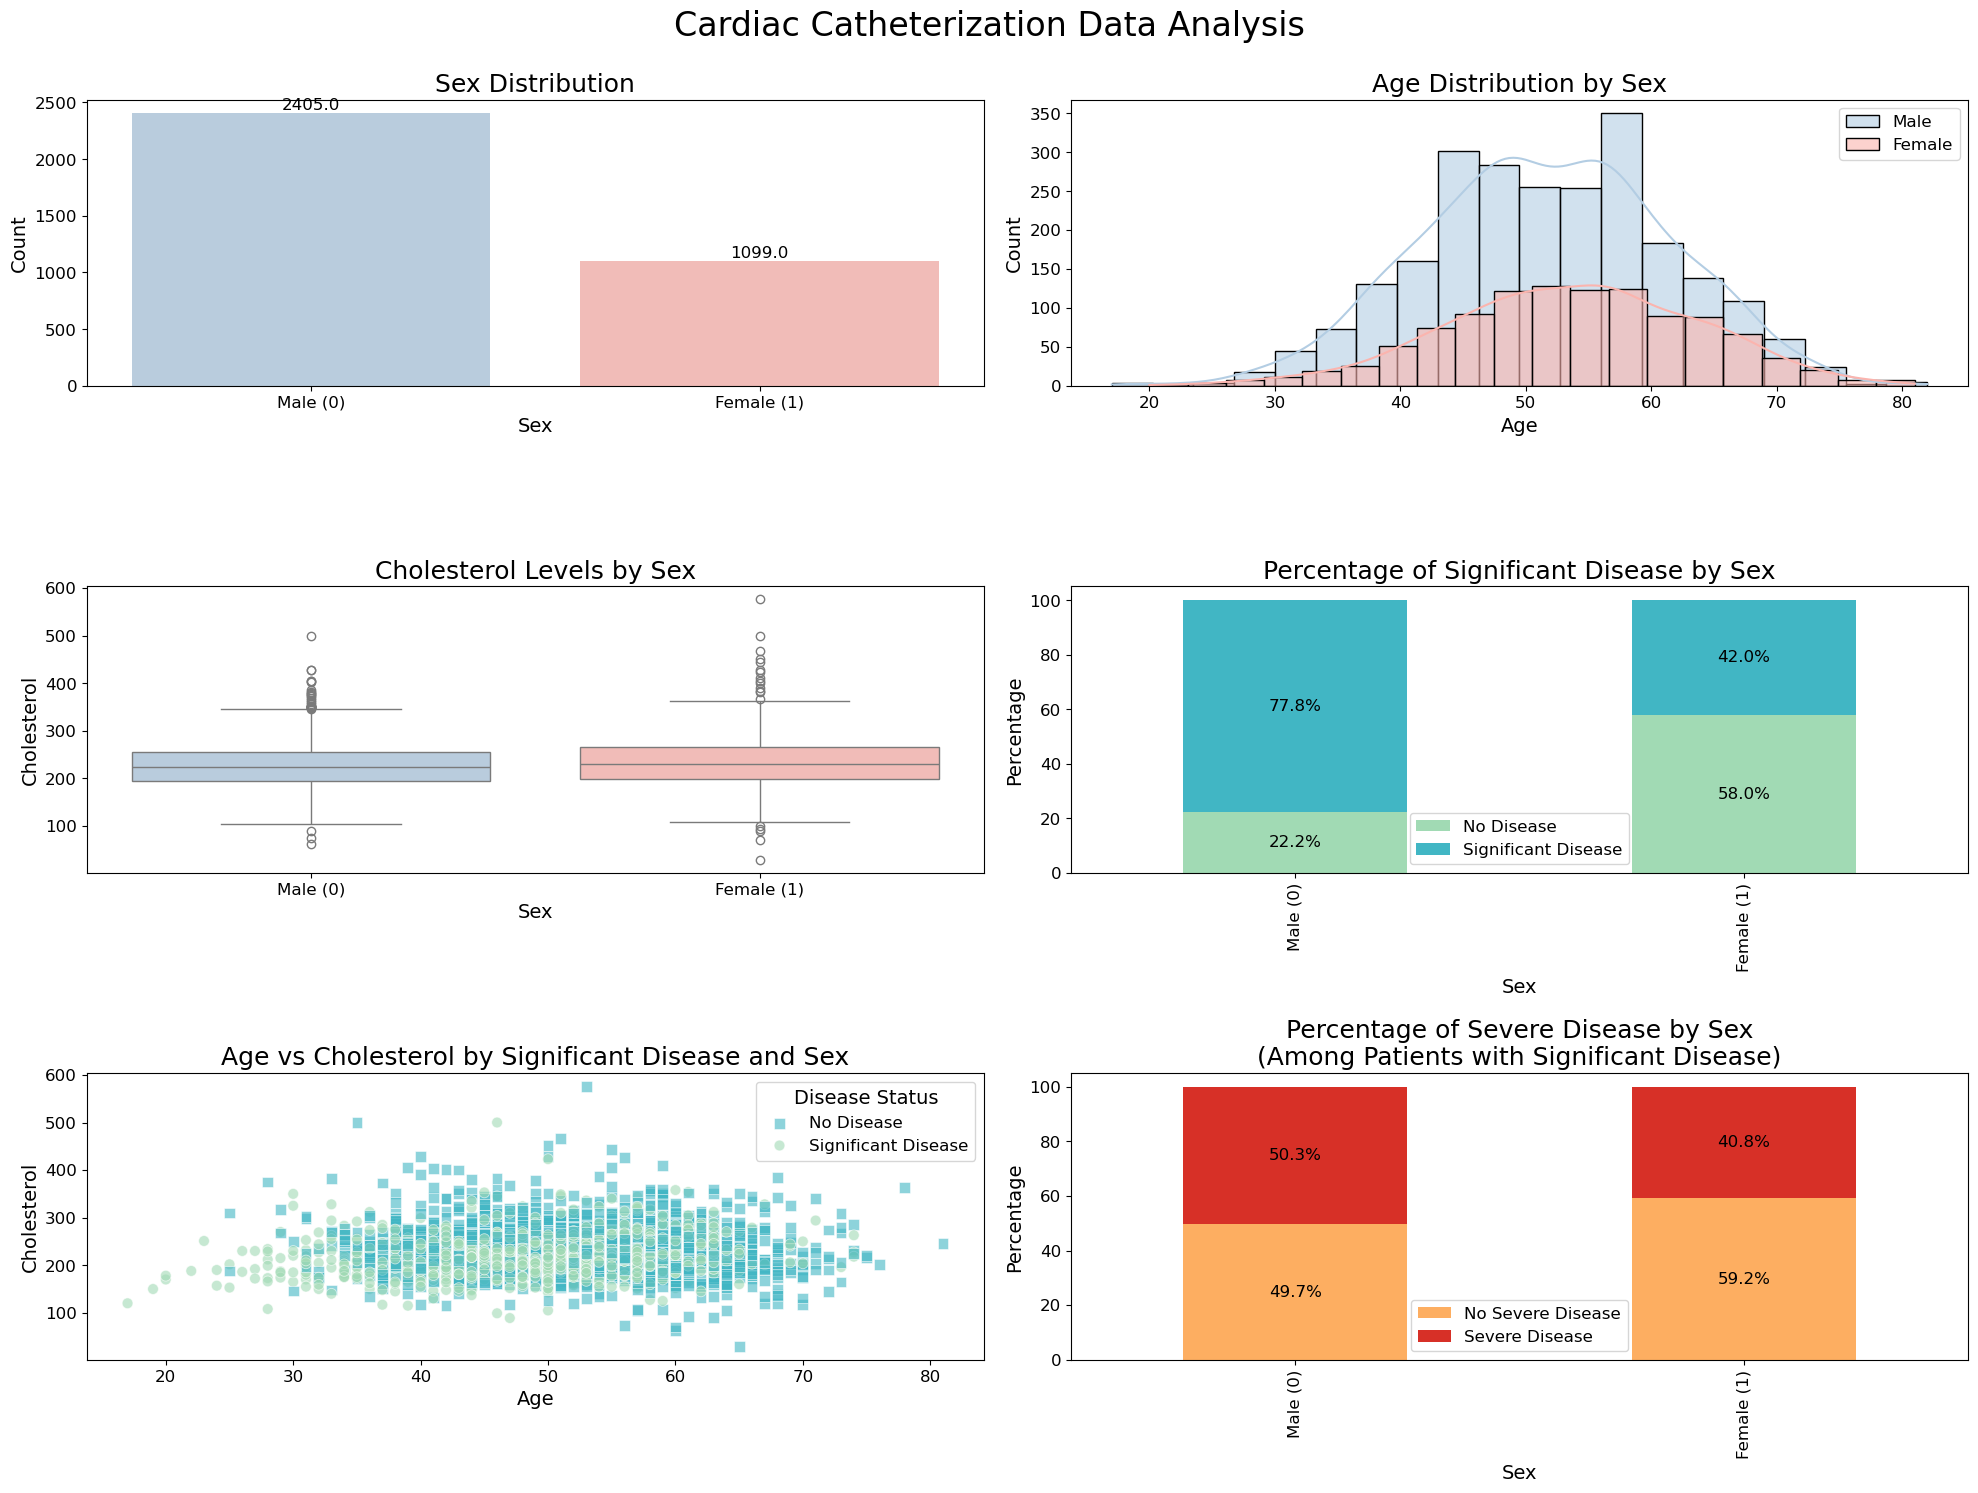

In [19]:
# modifying the image to remove the key findings box - prompt #1:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load the dataset
df = pd.read_csv('Cardiac_Catheretization_Diagnosis.csv')

# Set up the figure with subplots for storytelling visuals
plt.figure(figsize=(20, 15))

# Create a 3x2 grid of subplots
fig, axes = plt.subplots(3, 2, figsize=(20, 15))
fig.suptitle('Cardiac Catheterization Data Analysis', fontsize=24, y=0.98)

# Plot 1: Sex Distribution (0=Male, 1=Female)
sns.countplot(x='sex', data=df, palette=['#b3cde3', '#fbb4ae'], ax=axes[0, 0])
axes[0, 0].set_xlabel('Sex', fontsize=14)
axes[0, 0].set_ylabel('Count', fontsize=14)
axes[0, 0].set_title('Sex Distribution', fontsize=18)
axes[0, 0].set_xticklabels(['Male (0)', 'Female (1)'])

# Add count labels on top of bars
for i, p in enumerate(axes[0, 0].patches):
    height = p.get_height()
    axes[0, 0].text(p.get_x() + p.get_width()/2., height + 30,
                   f'{height}', ha="center", fontsize=12)

# Plot 2: Age Distribution by Sex
for sex_value, sex_label, color in [(0, 'Male', '#b3cde3'), (1, 'Female', '#fbb4ae')]:
    subset = df[df['sex'] == sex_value]
    sns.histplot(subset['age'], bins=20, kde=True, 
                label=sex_label, color=color, alpha=0.6, ax=axes[0, 1])
axes[0, 1].set_xlabel('Age', fontsize=14)
axes[0, 1].set_ylabel('Count', fontsize=14)
axes[0, 1].set_title('Age Distribution by Sex', fontsize=18)
axes[0, 1].legend(fontsize=12)

# Plot 3: Cholesterol Levels by Sex
sns.boxplot(x='sex', y='choleste', data=df, palette=['#b3cde3', '#fbb4ae'], ax=axes[1, 0])
axes[1, 0].set_xlabel('Sex', fontsize=14)
axes[1, 0].set_xticklabels(['Male (0)', 'Female (1)'])
axes[1, 0].set_ylabel('Cholesterol', fontsize=14)
axes[1, 0].set_title('Cholesterol Levels by Sex', fontsize=18)

# Plot 4: Percentage of Significant Disease by Sex
ct = pd.crosstab(df['sex'], df['sigdz'])
ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100
ct_pct.plot(kind='bar', stacked=True, color=['#a1dab4', '#41b6c4'], ax=axes[1, 1])
axes[1, 1].set_xlabel('Sex', fontsize=14)
axes[1, 1].set_xticklabels(['Male (0)', 'Female (1)'])
axes[1, 1].set_ylabel('Percentage', fontsize=14)
axes[1, 1].set_title('Percentage of Significant Disease by Sex', fontsize=18)
axes[1, 1].legend(['No Disease', 'Significant Disease'], fontsize=12)

# Add percentage labels on bars
for i, p in enumerate(axes[1, 1].patches):
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy() 
    if height > 5:  # Only label if percentage is significant
        axes[1, 1].annotate(f'{height:.1f}%', (x + width/2, y + height/2), 
                    ha='center', va='center', fontsize=12)

# Plot 5: Age vs Cholesterol Scatter Plot with Disease Status
colors = {0: '#a1dab4', 1: '#41b6c4'}
markers = {0: 'o', 1: 's'}

for sex_value in [0, 1]:
    subset = df[df['sex'] == sex_value]
    sns.scatterplot(x='age', y='choleste', hue='sigdz', data=subset, palette=colors, 
                    style='sigdz', markers=markers, alpha=0.6, s=60, ax=axes[2, 0])
axes[2, 0].set_xlabel('Age', fontsize=14)
axes[2, 0].set_ylabel('Cholesterol', fontsize=14)
axes[2, 0].set_title('Age vs Cholesterol by Significant Disease and Sex', fontsize=18)
axes[2, 0].legend(['No Disease', 'Significant Disease'], fontsize=12, title='Disease Status')

# Plot 6: Percentage of Severe Disease by Sex (for patients with significant disease)
sigdz_patients = df[df['sigdz'] == 1]
ct_severe = pd.crosstab(sigdz_patients['sex'], sigdz_patients['tvdlm'])
ct_severe_pct = ct_severe.div(ct_severe.sum(axis=1), axis=0) * 100
ct_severe_pct.plot(kind='bar', stacked=True, color=['#fdae61', '#d73027'], ax=axes[2, 1])
axes[2, 1].set_xlabel('Sex', fontsize=14)
axes[2, 1].set_xticklabels(['Male (0)', 'Female (1)'])
axes[2, 1].set_ylabel('Percentage', fontsize=14)
axes[2, 1].set_title('Percentage of Severe Disease by Sex\n(Among Patients with Significant Disease)', fontsize=18)
axes[2, 1].legend(['No Severe Disease', 'Severe Disease'], fontsize=12)

# Add percentage labels on bars
for i, p in enumerate(axes[2, 1].patches):
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy() 
    if height > 5:  # Only label if percentage is significant
        axes[2, 1].annotate(f'{height:.1f}%', (x + width/2, y + height/2), 
                    ha='center', va='center', fontsize=12)

# Adjust layout
plt.tight_layout()
plt.subplots_adjust(top=0.92, bottom=0.08)
plt.show()


/var/folders/7b/slgnw5wj06z2j76zhdtpnrdc0000gn/T/ipykernel_8786/334897253.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='sex', y='choleste', data=df, palette=['#0072B2', '#E69F00'], ax=axes[0, 2%2])
/var/folders/7b/slgnw5wj06z2j76zhdtpnrdc0000gn/T/ipykernel_8786/334897253.py:44: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0, 2%2].set_xticklabels(['Male (0)', 'Female (1)'])


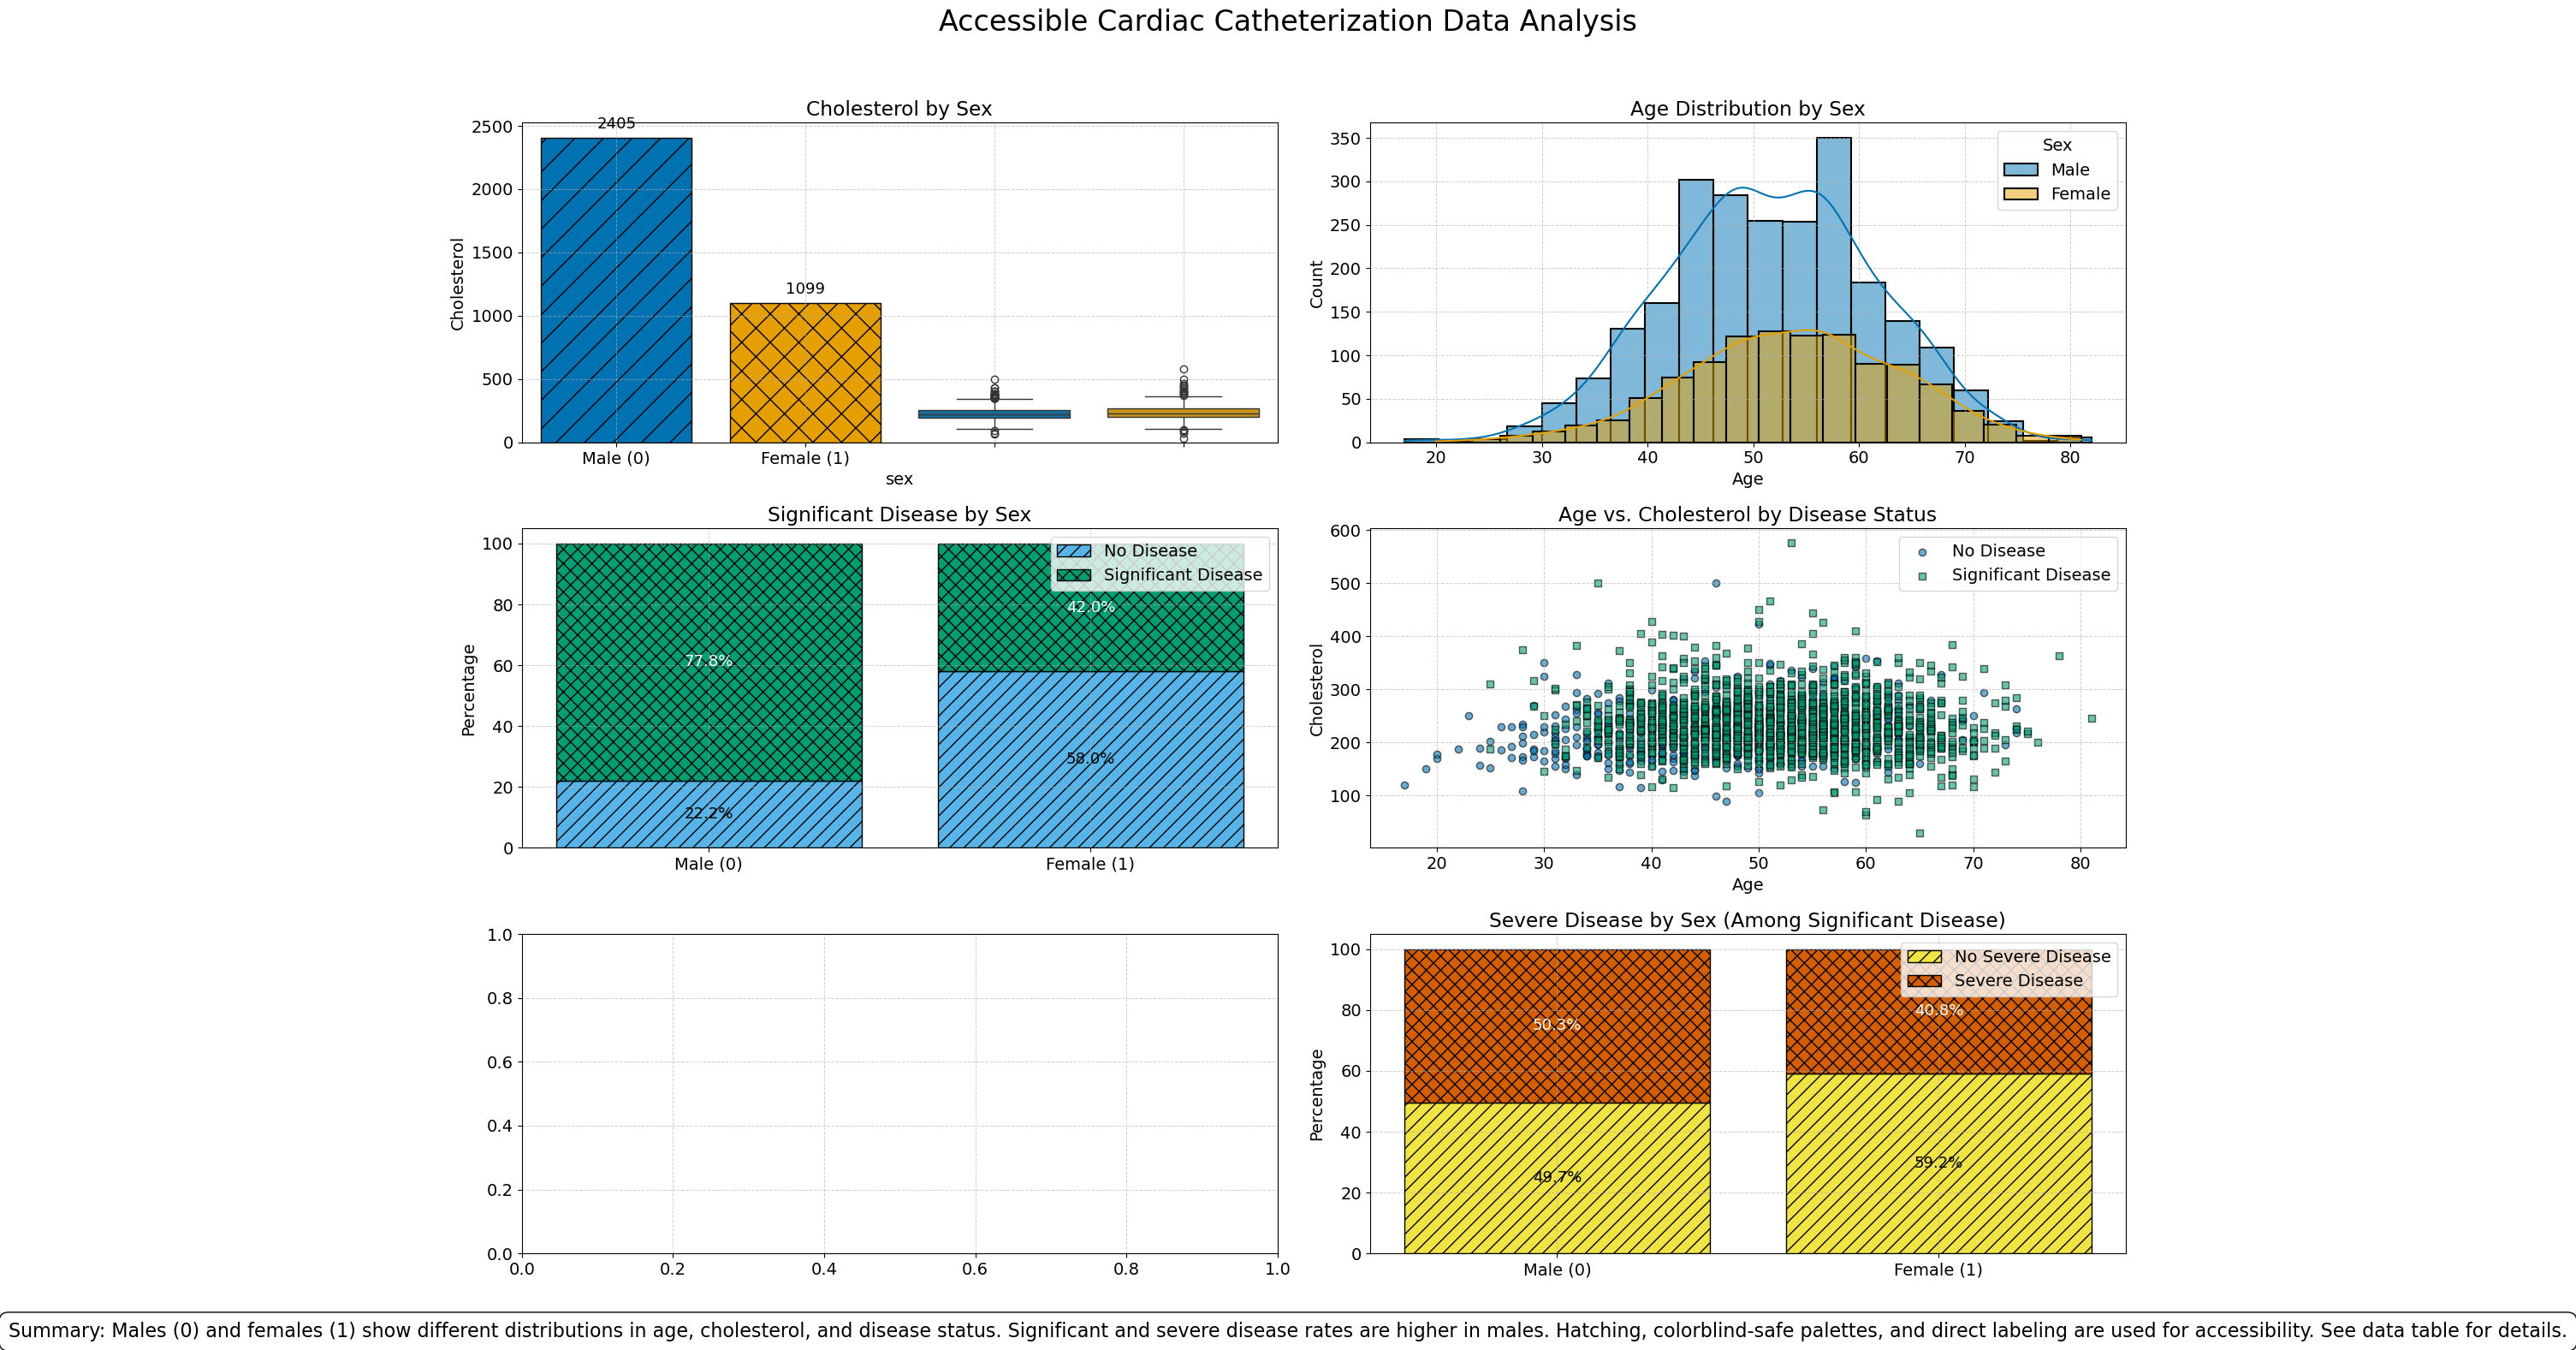

In [3]:
# modifying output to improve visualizations for accessibility:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load data
df = pd.read_csv('Cardiac_Catheretization_Diagnosis.csv')

# Set colorblind-friendly style and font
plt.style.use('seaborn-v0_8-colorblind')
plt.rcParams.update({'font.size': 14, 'font.family': 'DejaVu Sans'})

# Prepare data for stacked bar plots
sigdz_ct = pd.crosstab(df['sex'], df['sigdz'], normalize='index') * 100
tvdlm_ct = pd.crosstab(df[df['sigdz'] == 1]['sex'], df[df['sigdz'] == 1]['tvdlm'], normalize='index') * 100

fig, axes = plt.subplots(3, 2, figsize=(20, 16))
fig.suptitle('Accessible Cardiac Catheterization Data Analysis', fontsize=24, y=0.98)

# 1. Sex Distribution with hatching
bars = axes[0, 0].bar(['Male (0)', 'Female (1)'], df['sex'].value_counts().sort_index(), 
                      color=['#0072B2', '#E69F00'], edgecolor='black')
patterns = ['/', 'x']
for bar, pattern in zip(bars, patterns):
    bar.set_hatch(pattern)
axes[0, 0].set_title('Sex Distribution')
axes[0, 0].set_ylabel('Count')
for bar in bars:
    height = bar.get_height()
    axes[0, 0].text(bar.get_x() + bar.get_width()/2, height + 50, f'{int(height)}', ha='center', va='bottom', fontsize=13)

# 2. Age Distribution by Sex (histogram with KDE, high contrast lines)
for sex, color, pattern, label in zip([0, 1], ['#0072B2', '#E69F00'], ['/', 'x'], ['Male', 'Female']):
    subset = df[df['sex'] == sex]
    sns.histplot(subset['age'], bins=20, kde=True, color=color, label=label, alpha=0.5, ax=axes[0, 1], edgecolor='black', linewidth=1.5)
axes[0, 1].set_title('Age Distribution by Sex')
axes[0, 1].set_xlabel('Age')
axes[0, 1].set_ylabel('Count')
axes[0, 1].legend(title='Sex', loc='upper right')

# 3. Cholesterol by Sex (boxplot with hatching)
sns.boxplot(x='sex', y='choleste', data=df, palette=['#0072B2', '#E69F00'], ax=axes[0, 2%2])
axes[0, 2%2].set_xticklabels(['Male (0)', 'Female (1)'])
axes[0, 2%2].set_title('Cholesterol by Sex')
axes[0, 2%2].set_ylabel('Cholesterol')
# Add hatching to boxes
for i, box in enumerate(axes[0, 2%2].artists):
    box.set_hatch(patterns[i])

# 4. Stacked Bar: Significant Disease by Sex (add hatching and direct labels)
bars = axes[1, 0].bar(['Male (0)', 'Female (1)'], sigdz_ct[0], label='No Disease', color='#56B4E9', edgecolor='black', hatch='//')
bars2 = axes[1, 0].bar(['Male (0)', 'Female (1)'], sigdz_ct[1], bottom=sigdz_ct[0], label='Significant Disease', color='#009E73', edgecolor='black', hatch='xx')
axes[1, 0].set_title('Significant Disease by Sex')
axes[1, 0].set_ylabel('Percentage')
for i, (no, yes) in enumerate(zip(sigdz_ct[0], sigdz_ct[1])):
    axes[1, 0].text(i, no/2, f'{no:.1f}%', ha='center', va='center', color='black', fontsize=13)
    axes[1, 0].text(i, no + yes/2, f'{yes:.1f}%', ha='center', va='center', color='white', fontsize=13)
axes[1, 0].legend(loc='upper right')

# 5. Age vs. Cholesterol by Disease Status (shapes, high contrast, direct label)
markers = {0: 'o', 1: 's'}
for sigdz in [0, 1]:
    subset = df[df['sigdz'] == sigdz]
    axes[1, 1].scatter(subset['age'], subset['choleste'], 
                       c='#0072B2' if sigdz == 0 else '#009E73', 
                       marker=markers[sigdz], alpha=0.6, label='No Disease' if sigdz == 0 else 'Significant Disease', edgecolor='black')
axes[1, 1].set_title('Age vs. Cholesterol by Disease Status')
axes[1, 1].set_xlabel('Age')
axes[1, 1].set_ylabel('Cholesterol')
axes[1, 1].legend(loc='upper right')

# 6. Stacked Bar: Severe Disease by Sex among sigdz=1 (with hatching and direct labels)
bars = axes[2, 1].bar(['Male (0)', 'Female (1)'], tvdlm_ct[0], label='No Severe Disease', color='#F0E442', edgecolor='black', hatch='//')
bars2 = axes[2, 1].bar(['Male (0)', 'Female (1)'], tvdlm_ct[1], bottom=tvdlm_ct[0], label='Severe Disease', color='#D55E00', edgecolor='black', hatch='xx')
axes[2, 1].set_title('Severe Disease by Sex (Among Significant Disease)')
axes[2, 1].set_ylabel('Percentage')
for i, (no, yes) in enumerate(zip(tvdlm_ct[0], tvdlm_ct[1])):
    axes[2, 1].text(i, no/2, f'{no:.1f}%', ha='center', va='center', color='black', fontsize=13)
    axes[2, 1].text(i, no + yes/2, f'{yes:.1f}%', ha='center', va='center', color='white', fontsize=13)
axes[2, 1].legend(loc='upper right')

# Remove legends where not needed, add grid for readability
for ax in axes.flat:
    ax.grid(True, linestyle='--', linewidth=0.7, alpha=0.6)

# Add a text summary for screen readers and context
fig.text(0.5, 0.01, 
    ("Summary: Males (0) and females (1) show different distributions in age, cholesterol, and disease status. "
     "Significant and severe disease rates are higher in males. Hatching, colorblind-safe palettes, "
     "and direct labeling are used for accessibility. See data table for details."),
    ha='center', fontsize=16, bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.5'))

plt.tight_layout(rect=[0, 0.04, 1, 0.96])
plt.show()


/var/folders/7b/slgnw5wj06z2j76zhdtpnrdc0000gn/T/ipykernel_8786/2997790232.py:203: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.05, 1, 0.95])


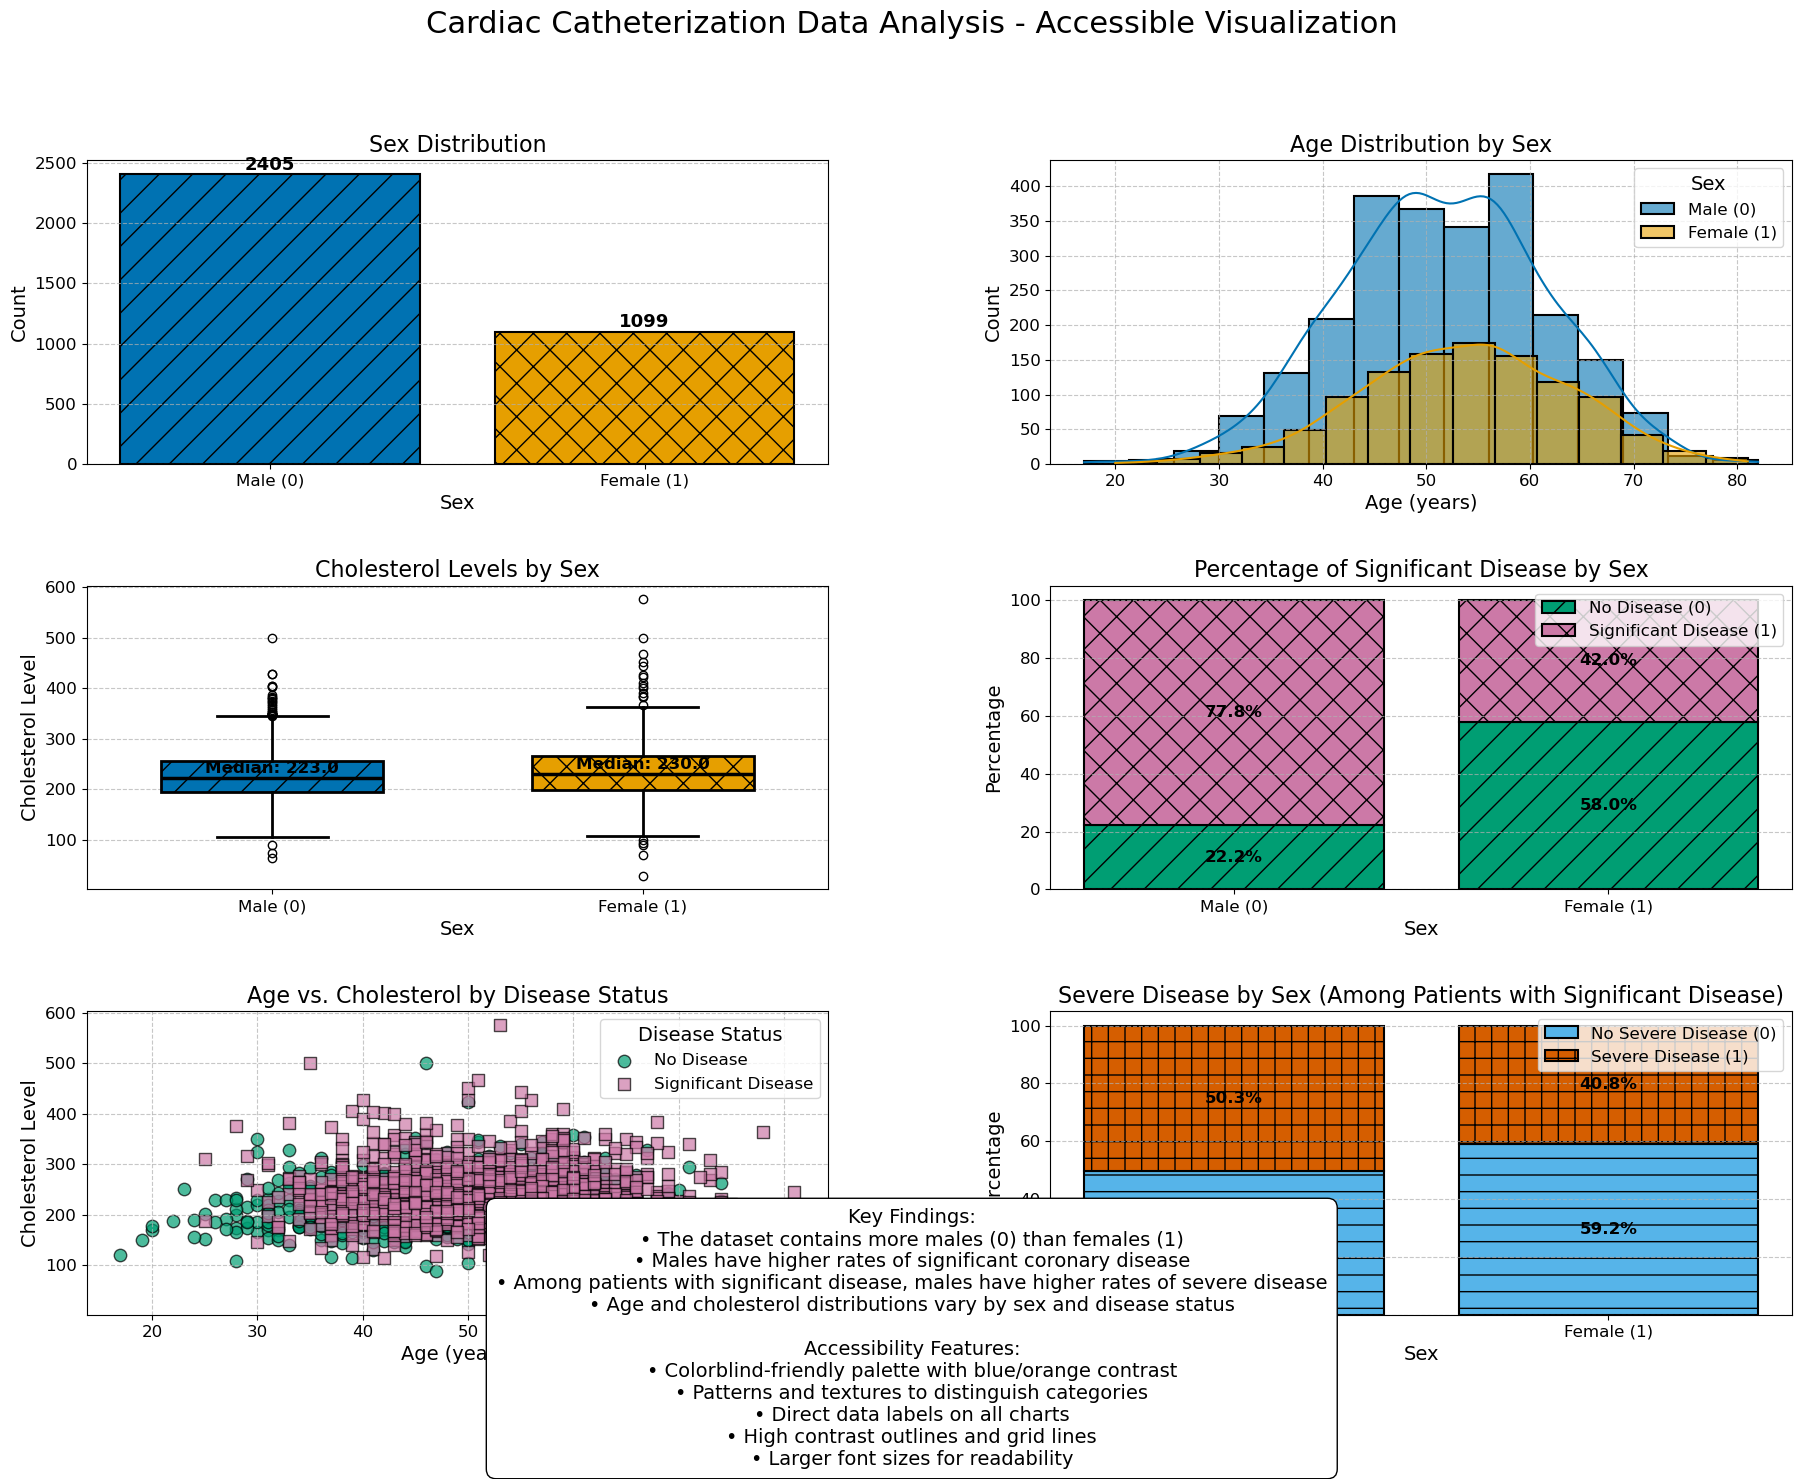

In [15]:
# improving the visualizations for accessibility - prompt #2:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

# Set up for accessibility
plt.rcParams.update({
    'font.size': 14,
    'font.family': 'sans-serif',
    'axes.labelsize': 14,
    'axes.titlesize': 16,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
    'figure.titlesize': 20
})

# Load the dataset
df = pd.read_csv('Cardiac_Catheretization_Diagnosis.csv')

# Create a figure with subplots
fig = plt.figure(figsize=(22, 15))
fig.suptitle('Cardiac Catheterization Data Analysis - Accessible Visualization', fontsize=22, y=0.98)

# Define a colorblind-friendly palette
# Using blue and orange which work well for most forms of color blindness
colors_sex = ['#0072B2', '#E69F00']  # Blue for Male (0), Orange for Female (1)
colors_disease = ['#009E73', '#CC79A7']  # Green for No Disease, Pink for Disease

# Create a 3x2 grid of subplots
gs = fig.add_gridspec(3, 2, hspace=0.4, wspace=0.3)

# 1. Sex Distribution with hatching and direct labels
ax1 = fig.add_subplot(gs[0, 0])
sex_counts = df['sex'].value_counts().sort_index()
bars = ax1.bar(['Male (0)', 'Female (1)'], sex_counts, color=colors_sex, edgecolor='black', linewidth=1.5)

# Add hatching for additional visual differentiation
patterns = ['/', 'x']
for bar, pattern in zip(bars, patterns):
    bar.set_hatch(pattern)

# Add direct count labels on bars
for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, height + 5, f'{int(height)}',
             ha='center', va='bottom', fontsize=13, fontweight='bold')

ax1.set_xlabel('Sex')
ax1.set_ylabel('Count')
ax1.set_title('Sex Distribution')
ax1.grid(axis='y', linestyle='--', alpha=0.7)

# 2. Age Distribution by Sex with high contrast and patterns
ax2 = fig.add_subplot(gs[0, 1])
for i, (sex_val, label) in enumerate([(0, 'Male (0)'), (1, 'Female (1)')]):
    subset = df[df['sex'] == sex_val]
    sns.histplot(subset['age'], bins=15, kde=True, color=colors_sex[i], 
                 label=label, alpha=0.6, ax=ax2, edgecolor='black', linewidth=1.5)

ax2.set_xlabel('Age (years)')
ax2.set_ylabel('Count')
ax2.set_title('Age Distribution by Sex')
ax2.legend(title='Sex')
ax2.grid(linestyle='--', alpha=0.7)

# 3. Cholesterol by Sex with boxplot hatching
ax3 = fig.add_subplot(gs[1, 0])
boxprops = dict(linestyle='-', linewidth=2, color='black')
medianprops = dict(linestyle='-', linewidth=2.5, color='black')
whiskerprops = dict(linestyle='-', linewidth=2, color='black')
capprops = dict(linestyle='-', linewidth=2, color='black')

# Create boxplots with distinct patterns
boxplots = ax3.boxplot([df[df['sex'] == 0]['choleste'].dropna(), 
                       df[df['sex'] == 1]['choleste'].dropna()],
                       patch_artist=True, positions=[0, 1], widths=0.6,
                       boxprops=boxprops, medianprops=medianprops,
                       whiskerprops=whiskerprops, capprops=capprops)

# Color and pattern the boxes
for i, box in enumerate(boxplots['boxes']):
    box.set_facecolor(colors_sex[i])
    box.set_hatch(patterns[i])

ax3.set_xticklabels(['Male (0)', 'Female (1)'])
ax3.set_xlabel('Sex')
ax3.set_ylabel('Cholesterol Level')
ax3.set_title('Cholesterol Levels by Sex')
ax3.grid(axis='y', linestyle='--', alpha=0.7)

# Add median values as text
for i, sex_val in enumerate([0, 1]):
    median = df[df['sex'] == sex_val]['choleste'].median()
    if not np.isnan(median):
        ax3.text(i, median + 10, f'Median: {median:.1f}', 
                 ha='center', fontsize=12, fontweight='bold')

# 4. Significant Disease by Sex with direct labels and patterns
ax4 = fig.add_subplot(gs[1, 1])
# Create a crosstab of sex and significant disease
ct = pd.crosstab(df['sex'], df['sigdz'])
ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100

# Create stacked bars with distinct patterns
bars1 = ax4.bar([0, 1], ct_pct[0], color='#009E73', edgecolor='black', linewidth=1.5, label='No Disease (0)')
bars2 = ax4.bar([0, 1], ct_pct[1], bottom=ct_pct[0], color='#CC79A7', edgecolor='black', linewidth=1.5, label='Significant Disease (1)')

# Add hatching for additional visual differentiation
for bar in bars1:
    bar.set_hatch('/')
for bar in bars2:
    bar.set_hatch('x')

# Add percentage labels directly on the bars
for i, (no, yes) in enumerate(zip(ct_pct[0], ct_pct[1])):
    # Label for No Disease
    ax4.text(i, no/2, f'{no:.1f}%', ha='center', va='center', fontsize=12, fontweight='bold')
    # Label for Significant Disease
    ax4.text(i, no + yes/2, f'{yes:.1f}%', ha='center', va='center', fontsize=12, fontweight='bold')

ax4.set_xticks([0, 1])
ax4.set_xticklabels(['Male (0)', 'Female (1)'])
ax4.set_xlabel('Sex')
ax4.set_ylabel('Percentage')
ax4.set_title('Percentage of Significant Disease by Sex')
ax4.legend(loc='upper right')
ax4.grid(axis='y', linestyle='--', alpha=0.7)

# 5. Age vs Cholesterol with shape and color encoding
ax5 = fig.add_subplot(gs[2, 0])
# Use different markers for disease status
markers = {0: 'o', 1: 's'}  # Circle for No Disease, Square for Disease

# Plot each disease status with different marker shapes
for sigdz in [0, 1]:
    subset = df[df['sigdz'] == sigdz].dropna(subset=['age', 'choleste'])
    ax5.scatter(subset['age'], subset['choleste'], 
                c=colors_disease[sigdz], marker=markers[sigdz], s=80, alpha=0.7,
                label=f'{"Significant Disease" if sigdz==1 else "No Disease"}',
                edgecolor='black', linewidth=1)

ax5.set_xlabel('Age (years)')
ax5.set_ylabel('Cholesterol Level')
ax5.set_title('Age vs. Cholesterol by Disease Status')
ax5.legend(title='Disease Status')
ax5.grid(linestyle='--', alpha=0.7)

# 6. Severe Disease among patients with Significant Disease
ax6 = fig.add_subplot(gs[2, 1])
# Filter for patients with significant disease
sigdz_patients = df[df['sigdz'] == 1]
# Create a crosstab of sex and severe disease
ct_severe = pd.crosstab(sigdz_patients['sex'], sigdz_patients['tvdlm'])
ct_severe_pct = ct_severe.div(ct_severe.sum(axis=1), axis=0) * 100

# Create stacked bars with distinct patterns
bars1 = ax6.bar([0, 1], ct_severe_pct[0], color='#56B4E9', edgecolor='black', linewidth=1.5, label='No Severe Disease (0)')
bars2 = ax6.bar([0, 1], ct_severe_pct[1], bottom=ct_severe_pct[0], color='#D55E00', edgecolor='black', linewidth=1.5, label='Severe Disease (1)')

# Add hatching for additional visual differentiation
for bar in bars1:
    bar.set_hatch('-')
for bar in bars2:
    bar.set_hatch('+')

# Add percentage labels directly on the bars
for i, (no, yes) in enumerate(zip(ct_severe_pct[0], ct_severe_pct[1])):
    # Label for No Severe Disease
    ax6.text(i, no/2, f'{no:.1f}%', ha='center', va='center', fontsize=12, fontweight='bold')
    # Label for Severe Disease
    ax6.text(i, no + yes/2, f'{yes:.1f}%', ha='center', va='center', fontsize=12, fontweight='bold')

ax6.set_xticks([0, 1])
ax6.set_xticklabels(['Male (0)', 'Female (1)'])
ax6.set_xlabel('Sex')
ax6.set_ylabel('Percentage')
ax6.set_title('Severe Disease by Sex (Among Patients with Significant Disease)')
ax6.legend(loc='upper right')
ax6.grid(axis='y', linestyle='--', alpha=0.7)

# Add a text box with key findings and accessibility information
textstr = '\n'.join((
    'Key Findings:',
    '• The dataset contains more males (0) than females (1)',
    '• Males have higher rates of significant coronary disease',
    '• Among patients with significant disease, males have higher rates of severe disease',
    '• Age and cholesterol distributions vary by sex and disease status',
    '',
    'Accessibility Features:',
    '• Colorblind-friendly palette with blue/orange contrast',
    '• Patterns and textures to distinguish categories',
    '• Direct data labels on all charts',
    '• High contrast outlines and grid lines',
    '• Larger font sizes for readability'
))

fig.text(0.5, 0.01, textstr, fontsize=14, 
         bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.5'),
         ha='center')

plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.savefig('cardiac_accessible_visualization.png', dpi=300, bbox_inches='tight')
plt.show()


/var/folders/7b/slgnw5wj06z2j76zhdtpnrdc0000gn/T/ipykernel_8786/1839122042.py:184: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.05, 1, 0.95])


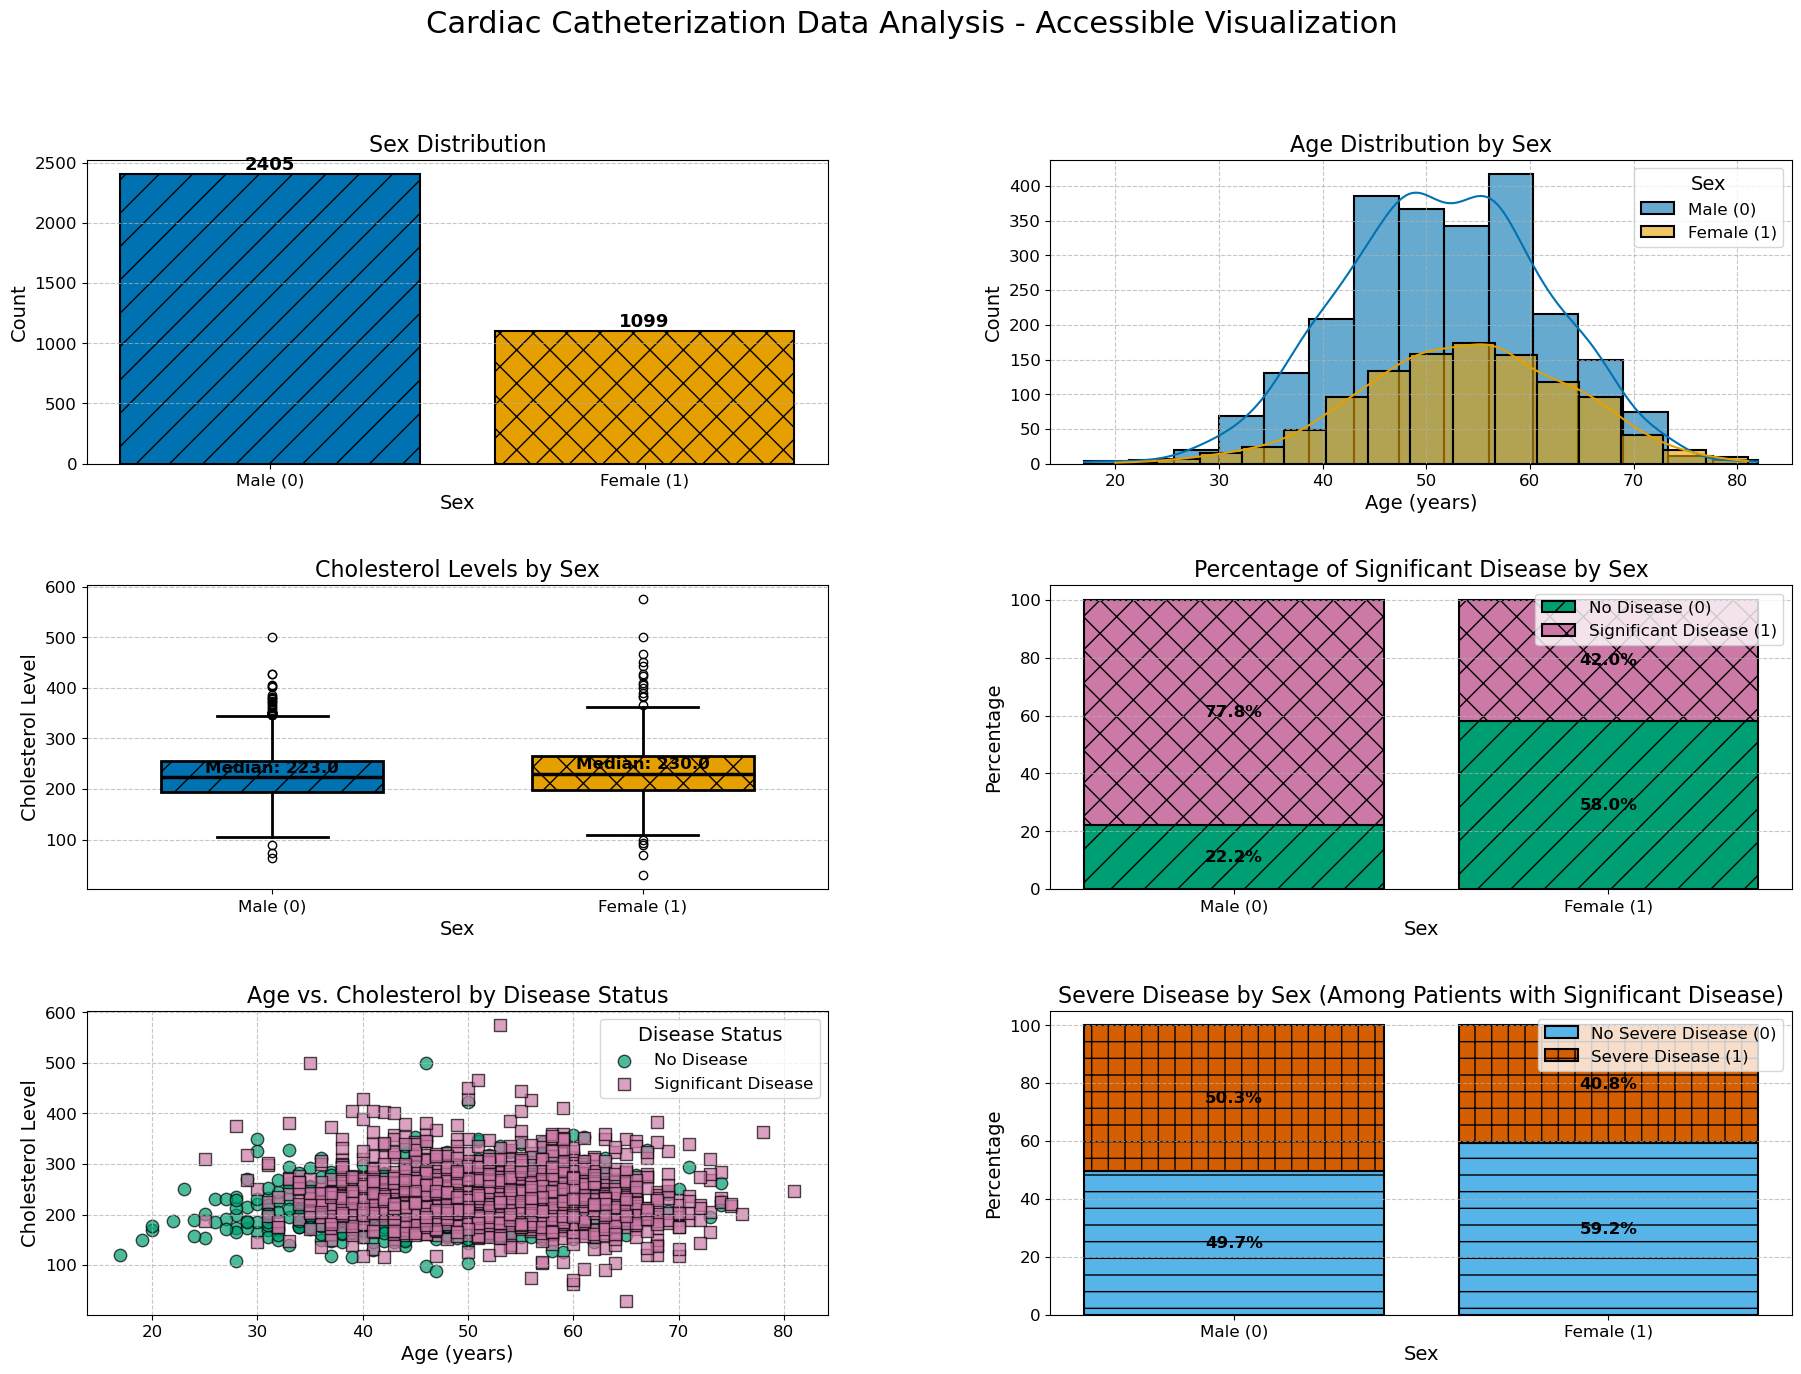

In [17]:
# removing the key findings box from the imgae - prompt #2:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

# Set up for accessibility
plt.rcParams.update({
    'font.size': 14,
    'font.family': 'sans-serif',
    'axes.labelsize': 14,
    'axes.titlesize': 16,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
    'figure.titlesize': 20
})

# Load the dataset
df = pd.read_csv('Cardiac_Catheretization_Diagnosis.csv')

# Create a figure with subplots
fig = plt.figure(figsize=(22, 15))
fig.suptitle('Cardiac Catheterization Data Analysis - Accessible Visualization', fontsize=22, y=0.98)

# Define a colorblind-friendly palette
# Using blue and orange which work well for most forms of color blindness
colors_sex = ['#0072B2', '#E69F00']  # Blue for Male (0), Orange for Female (1)
colors_disease = ['#009E73', '#CC79A7']  # Green for No Disease, Pink for Disease

# Create a 3x2 grid of subplots
gs = fig.add_gridspec(3, 2, hspace=0.4, wspace=0.3)

# 1. Sex Distribution with hatching and direct labels
ax1 = fig.add_subplot(gs[0, 0])
sex_counts = df['sex'].value_counts().sort_index()
bars = ax1.bar(['Male (0)', 'Female (1)'], sex_counts, color=colors_sex, edgecolor='black', linewidth=1.5)

# Add hatching for additional visual differentiation
patterns = ['/', 'x']
for bar, pattern in zip(bars, patterns):
    bar.set_hatch(pattern)

# Add direct count labels on bars
for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, height + 5, f'{int(height)}',
             ha='center', va='bottom', fontsize=13, fontweight='bold')

ax1.set_xlabel('Sex')
ax1.set_ylabel('Count')
ax1.set_title('Sex Distribution')
ax1.grid(axis='y', linestyle='--', alpha=0.7)

# 2. Age Distribution by Sex with high contrast and patterns
ax2 = fig.add_subplot(gs[0, 1])
for i, (sex_val, label) in enumerate([(0, 'Male (0)'), (1, 'Female (1)')]):
    subset = df[df['sex'] == sex_val]
    sns.histplot(subset['age'], bins=15, kde=True, color=colors_sex[i], 
                 label=label, alpha=0.6, ax=ax2, edgecolor='black', linewidth=1.5)

ax2.set_xlabel('Age (years)')
ax2.set_ylabel('Count')
ax2.set_title('Age Distribution by Sex')
ax2.legend(title='Sex')
ax2.grid(linestyle='--', alpha=0.7)

# 3. Cholesterol by Sex with boxplot hatching
ax3 = fig.add_subplot(gs[1, 0])
boxprops = dict(linestyle='-', linewidth=2, color='black')
medianprops = dict(linestyle='-', linewidth=2.5, color='black')
whiskerprops = dict(linestyle='-', linewidth=2, color='black')
capprops = dict(linestyle='-', linewidth=2, color='black')

# Create boxplots with distinct patterns
boxplots = ax3.boxplot([df[df['sex'] == 0]['choleste'].dropna(), 
                       df[df['sex'] == 1]['choleste'].dropna()],
                       patch_artist=True, positions=[0, 1], widths=0.6,
                       boxprops=boxprops, medianprops=medianprops,
                       whiskerprops=whiskerprops, capprops=capprops)

# Color and pattern the boxes
for i, box in enumerate(boxplots['boxes']):
    box.set_facecolor(colors_sex[i])
    box.set_hatch(patterns[i])

ax3.set_xticklabels(['Male (0)', 'Female (1)'])
ax3.set_xlabel('Sex')
ax3.set_ylabel('Cholesterol Level')
ax3.set_title('Cholesterol Levels by Sex')
ax3.grid(axis='y', linestyle='--', alpha=0.7)

# Add median values as text
for i, sex_val in enumerate([0, 1]):
    median = df[df['sex'] == sex_val]['choleste'].median()
    if not np.isnan(median):
        ax3.text(i, median + 10, f'Median: {median:.1f}', 
                 ha='center', fontsize=12, fontweight='bold')

# 4. Significant Disease by Sex with direct labels and patterns
ax4 = fig.add_subplot(gs[1, 1])
# Create a crosstab of sex and significant disease
ct = pd.crosstab(df['sex'], df['sigdz'])
ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100

# Create stacked bars with distinct patterns
bars1 = ax4.bar([0, 1], ct_pct[0], color='#009E73', edgecolor='black', linewidth=1.5, label='No Disease (0)')
bars2 = ax4.bar([0, 1], ct_pct[1], bottom=ct_pct[0], color='#CC79A7', edgecolor='black', linewidth=1.5, label='Significant Disease (1)')

# Add hatching for additional visual differentiation
for bar in bars1:
    bar.set_hatch('/')
for bar in bars2:
    bar.set_hatch('x')

# Add percentage labels directly on the bars
for i, (no, yes) in enumerate(zip(ct_pct[0], ct_pct[1])):
    # Label for No Disease
    ax4.text(i, no/2, f'{no:.1f}%', ha='center', va='center', fontsize=12, fontweight='bold')
    # Label for Significant Disease
    ax4.text(i, no + yes/2, f'{yes:.1f}%', ha='center', va='center', fontsize=12, fontweight='bold')

ax4.set_xticks([0, 1])
ax4.set_xticklabels(['Male (0)', 'Female (1)'])
ax4.set_xlabel('Sex')
ax4.set_ylabel('Percentage')
ax4.set_title('Percentage of Significant Disease by Sex')
ax4.legend(loc='upper right')
ax4.grid(axis='y', linestyle='--', alpha=0.7)

# 5. Age vs Cholesterol with shape and color encoding
ax5 = fig.add_subplot(gs[2, 0])
# Use different markers for disease status
markers = {0: 'o', 1: 's'}  # Circle for No Disease, Square for Disease

# Plot each disease status with different marker shapes
for sigdz in [0, 1]:
    subset = df[df['sigdz'] == sigdz].dropna(subset=['age', 'choleste'])
    ax5.scatter(subset['age'], subset['choleste'], 
                c=colors_disease[sigdz], marker=markers[sigdz], s=80, alpha=0.7,
                label=f'{"Significant Disease" if sigdz==1 else "No Disease"}',
                edgecolor='black', linewidth=1)

ax5.set_xlabel('Age (years)')
ax5.set_ylabel('Cholesterol Level')
ax5.set_title('Age vs. Cholesterol by Disease Status')
ax5.legend(title='Disease Status')
ax5.grid(linestyle='--', alpha=0.7)

# 6. Severe Disease among patients with Significant Disease
ax6 = fig.add_subplot(gs[2, 1])
# Filter for patients with significant disease
sigdz_patients = df[df['sigdz'] == 1]
# Create a crosstab of sex and severe disease
ct_severe = pd.crosstab(sigdz_patients['sex'], sigdz_patients['tvdlm'])
ct_severe_pct = ct_severe.div(ct_severe.sum(axis=1), axis=0) * 100

# Create stacked bars with distinct patterns
bars1 = ax6.bar([0, 1], ct_severe_pct[0], color='#56B4E9', edgecolor='black', linewidth=1.5, label='No Severe Disease (0)')
bars2 = ax6.bar([0, 1], ct_severe_pct[1], bottom=ct_severe_pct[0], color='#D55E00', edgecolor='black', linewidth=1.5, label='Severe Disease (1)')

# Add hatching for additional visual differentiation
for bar in bars1:
    bar.set_hatch('-')
for bar in bars2:
    bar.set_hatch('+')

# Add percentage labels directly on the bars
for i, (no, yes) in enumerate(zip(ct_severe_pct[0], ct_severe_pct[1])):
    # Label for No Severe Disease
    ax6.text(i, no/2, f'{no:.1f}%', ha='center', va='center', fontsize=12, fontweight='bold')
    # Label for Severe Disease
    ax6.text(i, no + yes/2, f'{yes:.1f}%', ha='center', va='center', fontsize=12, fontweight='bold')

ax6.set_xticks([0, 1])
ax6.set_xticklabels(['Male (0)', 'Female (1)'])
ax6.set_xlabel('Sex')
ax6.set_ylabel('Percentage')
ax6.set_title('Severe Disease by Sex (Among Patients with Significant Disease)')
ax6.legend(loc='upper right')
ax6.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.savefig('cardiac_accessible_visualization.png', dpi=300, bbox_inches='tight')
plt.show()

